---
---
# Ujian Akhir Semester Bengkel Koding
---
---
## Prediksi Customer Churn pada Dataset Sales and Marketing
**Nama :** Suluh Yoga Pratama  
**NIM  :** A11.2023.14979  
**Kelas :** DS-01  

# CAPSTONE 1 - MINGGU 1

# A. Data Understanding & EDA

## A.1. Eksplorasi Awal & Identifikasi Fitur

#### Load Library

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation & Selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Sampling
from imblearn.over_sampling import SMOTE

# Save Model
import joblib

**Analisis Library dan Tools Pemodelan**

Pada tahap ini, dilakukan proses **Import Library** untuk kebutuhan manipulasi data, visualisasi, hingga deployment model:

* **Data Manipulation:** `pandas` (DataFrame) dan `numpy` (operasi numerik).
* **Visualisasi:** `matplotlib.pyplot` dan `seaborn` untuk pembuatan grafik dan plot distribusi.
* **Scikit-Learn:**
    * **Preprocessing:** `LabelEncoder`, `OrdinalEncoder`, `StandardScaler`, `SimpleImputer` untuk transformasi data.
    * **Model:** `LogisticRegression`, `RandomForestClassifier`, `VotingClassifier`, `KNeighborsClassifier`.
* **Evaluasi & Seleksi:** `train_test_split`, `sklearn.metrics`, `GridSearchCV`, dan `RandomizedSearchCV`.
* **Imbalanced-learn:** `SMOTE` untuk menangani ketidakseimbangan kelas pada variabel target `churn`.
* **Joblib:** untuk menyimpan model terbaik dalam format `.pkl` guna keperluan deployment Streamlit.

#### Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Path file dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Bengkel_Koding/UAS/Sales and Marketing DataSet.csv'

# Membaca dataset
df = pd.read_csv(file_path)

# Menampilkan 5 data pertama
display(df.head())

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


**Koneksi Google Drive dan Pemuatan Dataset**

Dataset **Sales and Marketing Customer** berhasil dimuat dari Google Drive ke dalam DataFrame Pandas menggunakan `pd.read_csv()`. Fungsi `head()` digunakan untuk menampilkan 5 baris pertama sebagai inspeksi awal struktur data, memastikan seluruh kolom terbaca dengan benar sebelum dilanjutkan ke proses eksplorasi.

In [ ]:
# Menampilkan dimensi dataset
print("=== DIMENSI DATASET ===")
print(f"Jumlah Baris  : {df.shape[0]:,}")
print(f"Jumlah Kolom  : {df.shape[1]}")

=== DIMENSI DATASET ===
Jumlah Baris  : 15,000
Jumlah Kolom  : 30


**Informasi Dimensi Dataset**

Tahap ini dilakukan untuk mengetahui skala data secara keseluruhan menggunakan atribut `df.shape`. Dataset memiliki total **15.000 baris data** dan **30 kolom fitur** yang akan digunakan dalam proses analisis dan pemodelan prediksi churn.

In [ ]:
# Menampilkan informasi tipe data
print("=== INFORMASI DATASET ===")
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages

**Struktur Data dan Tipe Variabel**

Penggunaan fungsi `df.info()` bertujuan untuk meninjau ringkasan teknis dataset, yang mencakup identifikasi tipe data (numerik dan kategorikal) serta pendeteksian awal nilai yang hilang (*missing values*), seperti yang terlihat pada kolom **gender**, **age**, **total_spent**,**coupon_code**, **satisfaction_score**, guna menentukan strategi pembersihan data yang tepat sebelum memasuki tahap selanjutnya.

In [ ]:
# Statistik deskriptif
print("=== STATISTIK DESKRIPTIF ===")
display(df.describe())

=== STATISTIK DESKRIPTIF ===


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


**Statistik Deskriptif Dataset**

Penggunaan fungsi `df.describe()` memberikan ringkasan statistik untuk kolom numerik, yang mencakup nilai rata-rata, standar deviasi, serta rentang nilai minimum dan maksimum. Sebagai contoh analisis pada fitur **Age (Umur)**, dataset ini menunjukkan bahwa rata-rata penumpang berusia **35 tahun**, dengan rentang usia yang sangat luas mulai dari yang termuda yaitu **-4 tahun (tidak relevan)** hingga yang tertua mencapai **95 tahun**.

In [ ]:
# Identifikasi dan pengelompokan fitur berdasarkan tipenya
fitur_kategorikal = ['gender', 'country', 'city', 'acquisition_channel',
                      'device_type', 'subscription_type', 'coupon_code', 'payment_method']

fitur_datetime = ['signup_date', 'last_purchase_date']

fitur_biner = ['is_premium_user', 'discount_used', 'refund_requested', 'churn']

fitur_kontinu = ['age', 'avg_session_time', 'pages_per_session', 'email_open_rate',
                  'email_click_rate', 'total_spent', 'avg_order_value',
                  'satisfaction_score', 'marketing_spend_per_user', 'lifetime_value']

fitur_diskrit = ['total_visits', 'support_tickets', 'delivery_delay_days',
                  'nps_score', 'last_3_month_purchase_freq']

print("=== PENGELOMPOKAN FITUR ===")
print(f"\n1. Fitur Kategorikal ({len(fitur_kategorikal)} fitur):")
for f in fitur_kategorikal: print(f"   - {f}")
print(f"\n2. Fitur Datetime ({len(fitur_datetime)} fitur):")
for f in fitur_datetime: print(f"   - {f}")
print(f"\n3. Fitur Biner/Flag ({len(fitur_biner)} fitur):")
for f in fitur_biner: print(f"   - {f}")
print(f"\n4. Fitur Kontinu ({len(fitur_kontinu)} fitur):")
for f in fitur_kontinu: print(f"   - {f}")
print(f"\n5. Fitur Diskrit ({len(fitur_diskrit)} fitur):")
for f in fitur_diskrit: print(f"   - {f}")

=== PENGELOMPOKAN FITUR ===

1. Fitur Kategorikal (8 fitur):
   - gender
   - country
   - city
   - acquisition_channel
   - device_type
   - subscription_type
   - coupon_code
   - payment_method

2. Fitur Datetime (2 fitur):
   - signup_date
   - last_purchase_date

3. Fitur Biner/Flag (4 fitur):
   - is_premium_user
   - discount_used
   - refund_requested
   - churn

4. Fitur Kontinu (10 fitur):
   - age
   - avg_session_time
   - pages_per_session
   - email_open_rate
   - email_click_rate
   - total_spent
   - avg_order_value
   - satisfaction_score
   - marketing_spend_per_user
   - lifetime_value

5. Fitur Diskrit (5 fitur):
   - total_visits
   - support_tickets
   - delivery_delay_days
   - nps_score
   - last_3_month_purchase_freq


**Pengelompokan Fitur Berdasarkan Karakteristik Data**

Pada tahap ini, dilakukan klasifikasi variabel ke dalam lima kelompok untuk mempermudah strategi *preprocessing*:
- **Fitur Kategorikal:** Berisi data label non-numerik.
- **Fitur Datetime:** Kolom tanggal yang perlu dikonversi atau diekstrak fiturnya.
- **Fitur Biner/Flag:** Kolom bernilai 0 atau 1.
- **Fitur Kontinu:** Kolom numerik dengan rentang nilai luas.
- **Fitur Diskrit:** Kolom numerik cacahan.
- Kolom `customer_id` tidak dimasukkan ke kelompok manapun karena hanya merupakan identitas unik yang tidak relevan untuk pemodelan.

## A.2. Identifikasi Missing Value & Duplikasi Data

In [ ]:
# Menghitung persentase missing value
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

df_missing = pd.DataFrame({
    'Jumlah Missing': missing_counts,
    'Persentase (%)': missing_pct.round(4)
}).sort_values('Jumlah Missing', ascending=False)

print("=== REKAP MISSING VALUE PER KOLOM ===")
display(df_missing)
print(f"\nTotal kolom dengan missing value: {(missing_counts > 0).sum()}")
print(f"Total missing value keseluruhan : {missing_counts.sum():,}")

=== REKAP MISSING VALUE PER KOLOM ===


,Jumlah Missing,Persentase (%)
coupon_code,6133,40.8867
age,1200,8.0000
total_spent,1050,7.0000
gender,738,4.9200
satisfaction_score,702,4.6800
customer_id,0,0.0000
last_purchase_date,0,0.0000
acquisition_channel,0,0.0000
device_type,0,0.0000
subscription_type,0,0.0000



Total kolom dengan missing value: 5
Total missing value keseluruhan : 9,823


/tmp/ipykernel_8450/4073117360.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mv_cols['Jumlah Missing'].values, y=mv_cols.index, palette='Reds_r')


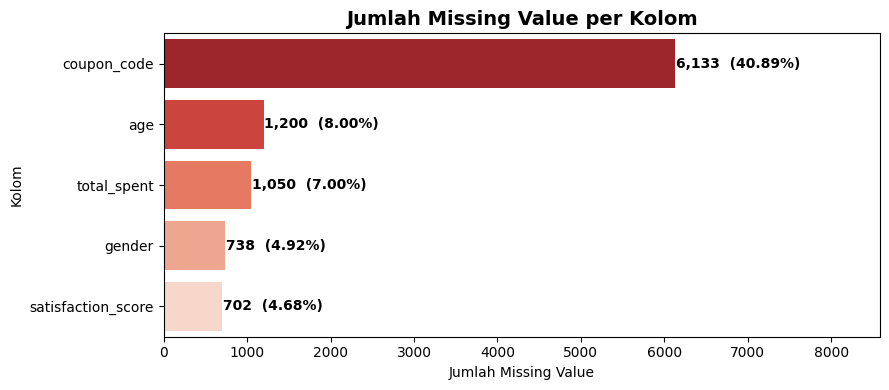

In [ ]:
# Visualisasi missing value
mv_cols = df_missing[df_missing['Jumlah Missing'] > 0]

if len(mv_cols) > 0:
    plt.figure(figsize=(9, max(4, len(mv_cols)*0.6)))
    ax = sns.barplot(x=mv_cols['Jumlah Missing'].values, y=mv_cols.index, palette='Reds_r')
    for i, (jumlah, pct) in enumerate(zip(mv_cols['Jumlah Missing'].values,
                                           mv_cols['Persentase (%)'].values)):
        ax.text(jumlah + 5, i, f'{jumlah:,}  ({pct:.2f}%)',
                va='center', fontsize=10, fontweight='bold')
    plt.title('Jumlah Missing Value per Kolom', fontsize=14, fontweight='bold')
    plt.xlabel('Jumlah Missing Value')
    plt.ylabel('Kolom')
    plt.xlim(0, mv_cols['Jumlah Missing'].max() * 1.4)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada missing value yang ditemukan pada dataset!")

**Identifikasi Nilai yang Hilang (Missing Value)**  

`df.isnull().sum()` mendeteksi kolom-kolom dengan nilai kosong. Diagram batang memvisualisasikan kolom kosong beserta persentasenya. Penanganan dilakukan pada tahap preprocessing menggunakan **imputasi median** (fitur numerik) dan **imputasi modus** (fitur kategorikal) agar tidak ada data yang terbuang.

In [ ]:
# Pengecekan data duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data yang terduplikasi : {jumlah_duplikat:,}")
print(f"Jumlah data keseluruhan       : {df.shape[0]:,}")
print(f"Persentase duplikat           : {(jumlah_duplikat/df.shape[0])*100:.4f}%")

Jumlah data yang terduplikasi : 0
Jumlah data keseluruhan       : 15,000
Persentase duplikat           : 0.0000%


**Pengecekan Data Duplikat**

Tahap ini dilakukan untuk memastikan validitas data dengan memeriksa keberadaan baris yang identik menggunakan fungsi `df.duplicated().sum()`. Hasil pengecekan menunjukkan bahwa tidak terdapat data yang terduplikasi (0 duplikat), sehingga setiap data dalam dataset bersifat unik dan siap digunakan untuk proses selanjutnya.

## A.3. Visualisasi Distribusi Data

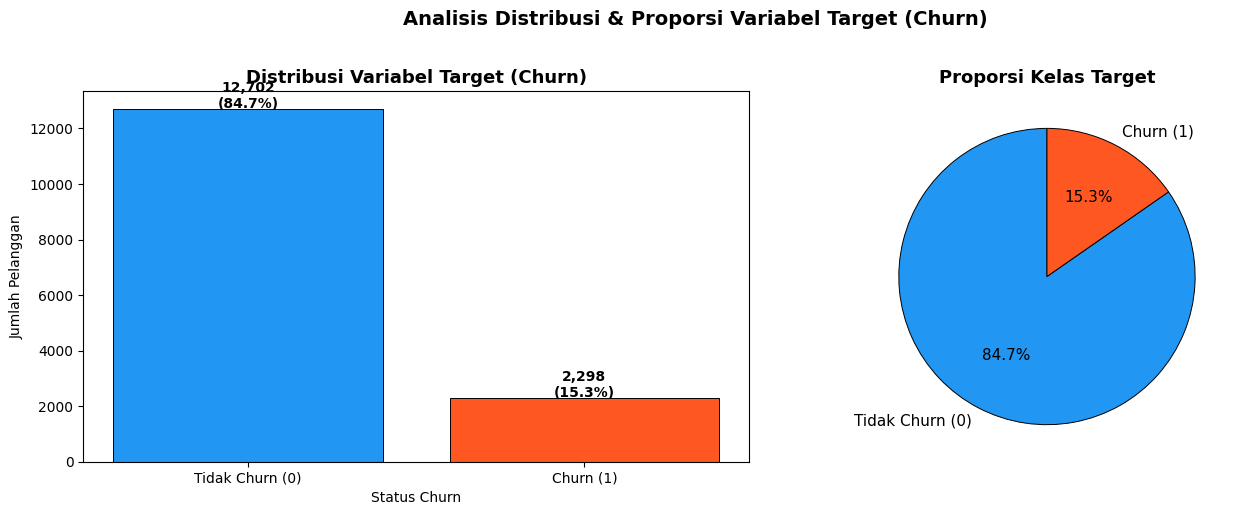


Detail Distribusi Kelas Target:
churn
0    12702
1     2298
Name: count, dtype: int64

Rasio imbalance: 5.53:1


In [ ]:
# Distribusi Variabel Target (Churn) - Bar Chart + Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df['churn'].value_counts().sort_index()
labels_target = ['Tidak Churn (0)', 'Churn (1)']
colors = ['#2196F3', '#FF5722']

# Bar Chart
bars = axes[0].bar(labels_target, target_counts.values,
                    color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribusi Variabel Target (Churn)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Churn')
axes[0].set_ylabel('Jumlah Pelanggan')
for bar, v in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30,
                  f'{v:,}\n({v/len(df)*100:.1f}%)',
                  ha='center', fontweight='bold', fontsize=10)

# Pie Chart
axes[1].pie(target_counts.values, labels=labels_target,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.7},
            textprops={'fontsize': 11})
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Distribusi & Proporsi Variabel Target (Churn)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nDetail Distribusi Kelas Target:")
print(target_counts)
print(f"\nRasio imbalance: {target_counts.max()/target_counts.min():.2f}:1")

**Analisis Distribusi dan Proporsi Variabel Target**

Visualisasi menggambarkan sebaran kelas pada variabel **Churn**. Terlihat **ketidakseimbangan kelas (*class imbalance*)** antara pelanggan *churn* dan *tidak churn*. Kondisi ini harus ditangani menggunakan **teknik sampling** pada tahap selanjutnya agar model tidak bias memprediksi kelas mayoritas secara berlebihan.

## A.4. Analisis Korelasi

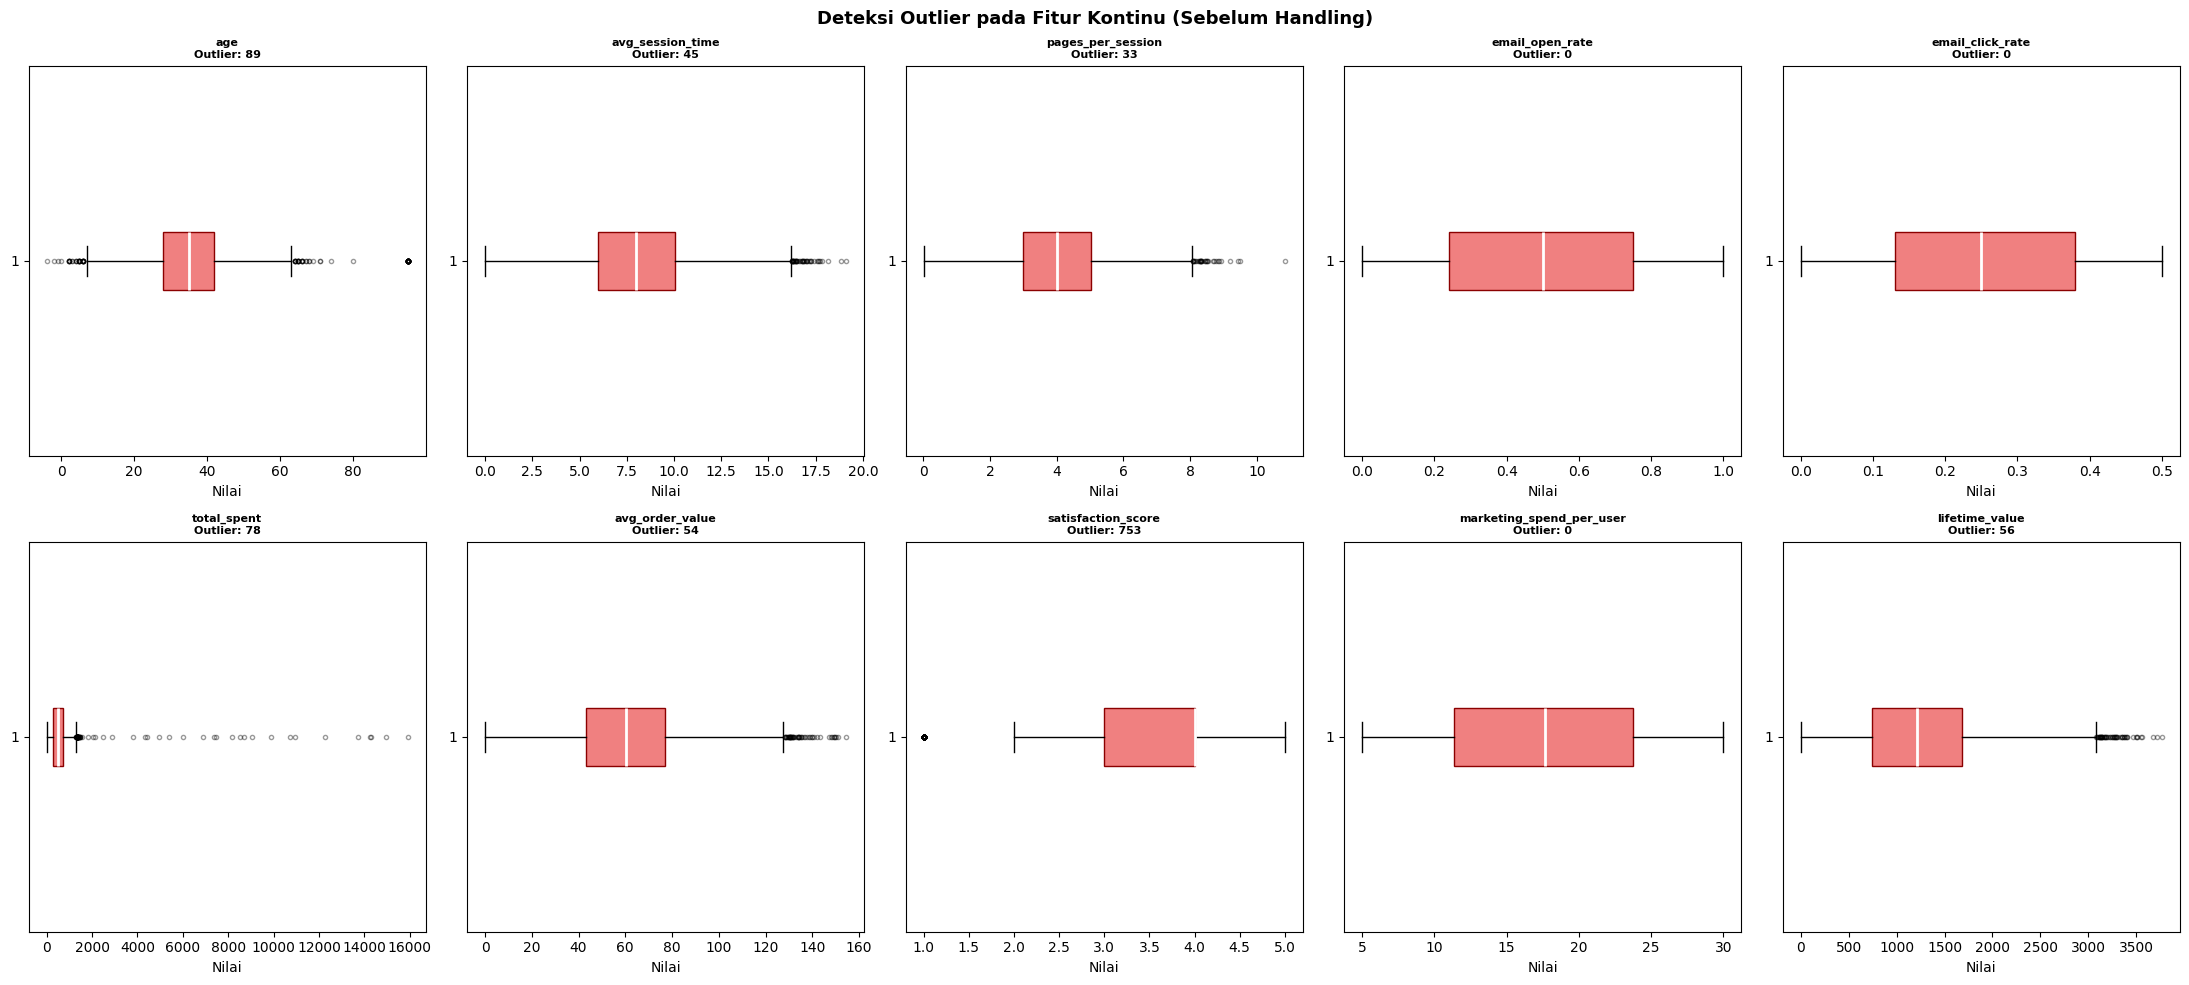

In [ ]:
# Deteksi Outlier menggunakan Boxplot pada Fitur Kontinu
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(fitur_kontinu):
    data = df[col].dropna()
    axes[i].boxplot(data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', color='red', markersize=3, alpha=0.4))
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    n_out = len(data[(data < Q1-1.5*IQR) | (data > Q3+1.5*IQR)])
    axes[i].set_title(f'{col}\nOutlier: {n_out:,}', fontsize=8, fontweight='bold')
    axes[i].set_xlabel('Nilai')

plt.suptitle('Deteksi Outlier pada Fitur Kontinu (Sebelum Handling)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Identifikasi Outlier pada Fitur Kontinu**

Boxplot digunakan untuk mendeteksi nilai-nilai ekstrem (*outlier*) menggunakan metode **IQR (Interquartile Range)**. Dari visualisasi di atas teridentifikasi outlier pada beberapa kolom seperti `total_spent`, `age`, `lifetime_value`, dan lain lain. Outlier ini akan ditangani menggunakan metode **Capping IQR** pada tahap preprocessing untuk menstabilkan distribusi data tanpa menghilangkan baris data.

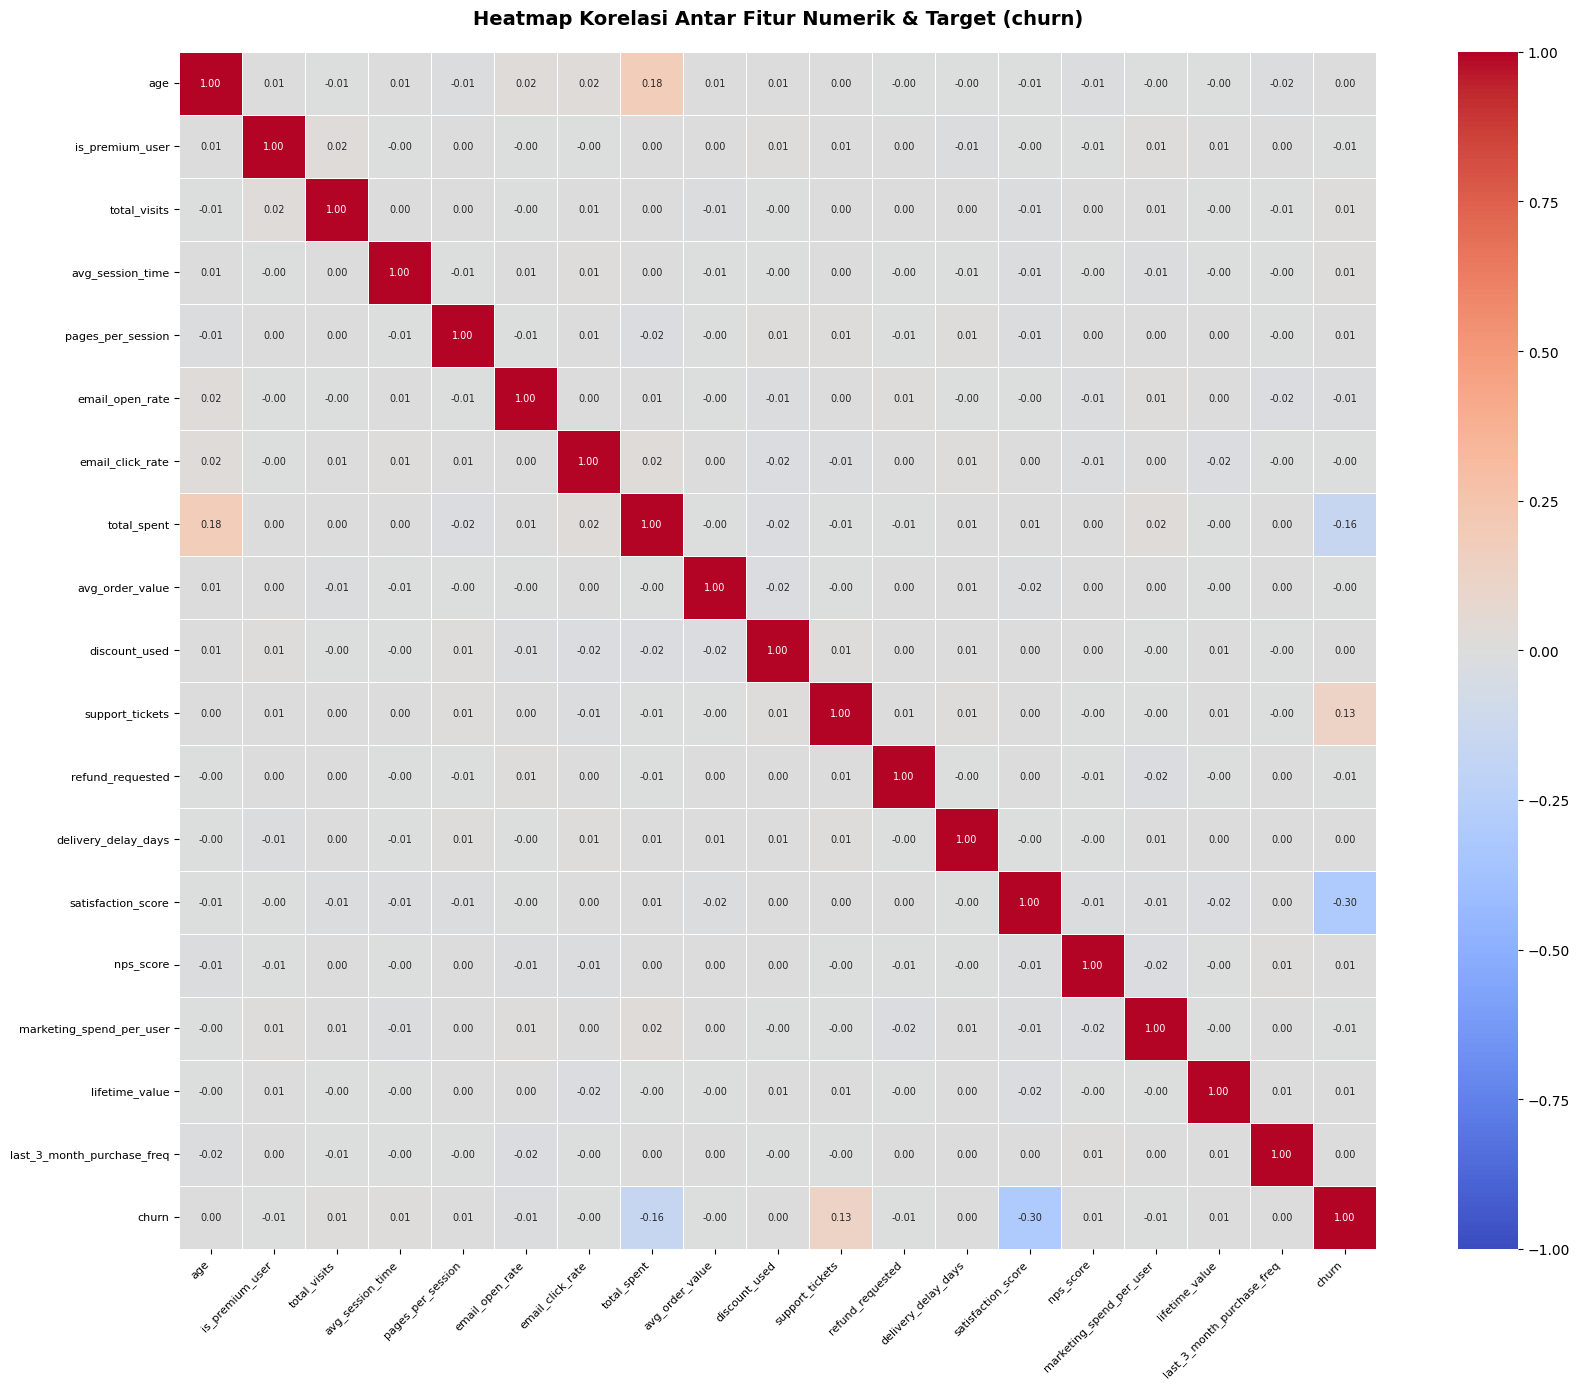

In [ ]:
# Heatmap Korelasi Fitur Numerik
df_corr = df.copy()
df_corr['churn'] = df_corr['churn'].astype(int)

# Pilih semua kolom numerik
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
# Hapus customer_id
numeric_cols = [c for c in numeric_cols if c != 'customer_id']
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Heatmap Korelasi Antar Fitur Numerik & Target (churn)',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

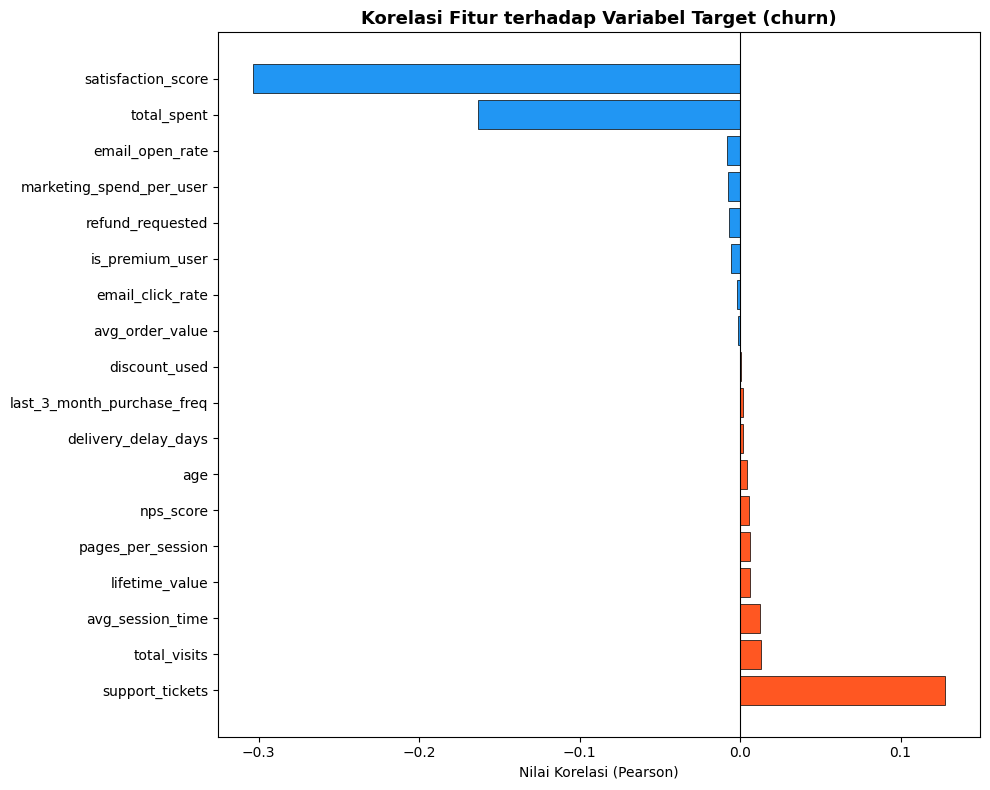

Top 5 Fitur dengan Korelasi TERTINGGI terhadap Churn:
support_tickets      0.127910
total_visits         0.013212
avg_session_time     0.012198
lifetime_value       0.006250
pages_per_session    0.005871
Name: churn, dtype: float64

Top 5 Fitur dengan Korelasi TERENDAH terhadap Churn:
refund_requested           -0.006959
marketing_spend_per_user   -0.007315
email_open_rate            -0.008439
total_spent                -0.163279
satisfaction_score         -0.303588
Name: churn, dtype: float64


In [ ]:
# Korelasi masing-masing fitur terhadap target (diurutkan)
target_corr = corr_matrix['churn'].drop('churn').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#FF5722' if v >= 0 else '#2196F3' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors,
          edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Korelasi Fitur terhadap Variabel Target (churn)',
          fontsize=13, fontweight='bold')
plt.xlabel('Nilai Korelasi (Pearson)')
plt.tight_layout()
plt.show()

print("Top 5 Fitur dengan Korelasi TERTINGGI terhadap Churn:")
print(target_corr.head())
print("\nTop 5 Fitur dengan Korelasi TERENDAH terhadap Churn:")
print(target_corr.tail())

**Analisis Korelasi Fitur terhadap Variabel Target**

Dari heatmap dan grafik korelasi, diperoleh beberapa insight penting:
- Fitur seperti `satisfaction_score` dan `total_spent` menunjukkan **korelasi negatif** terhadap churn (semakin tinggi kepuasan, semakin kecil kemungkinan pelanggan churn).
- Fitur `support_tickets` dan `total_visits` menunjukkan **korelasi positif** terhadap churn (semakin banyak tiket dan permintaan refund, semakin besar kemungkinan pelanggan churn).
- Beberapa fitur memiliki korelasi yang sangat rendah terhadap target, yang akan dikonfirmasi kembali melalui analisis **feature importance** pada tahap Hyperparameter Tuning.

---
# CAPSTONE 2 - MINGGU 2
---

# B. Direct Modeling

## Penentuan Variabel dan Pembagian Data

In [ ]:
# Buat salinan data untuk direct modeling (minimal preprocessing)
df_direct = df.copy()

# Hapus kolom tidak relevan
df_direct = df_direct.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'], errors='ignore')

# Tangani missing value dengan dropna (minimal preprocessing)
print(f"Jumlah baris sebelum drop missing: {df_direct.shape[0]:,}")
df_direct = df_direct.dropna()
print(f"Jumlah baris setelah drop missing : {df_direct.shape[0]:,}")

# Encoding fitur kategorikal dengan LabelEncoder
le = LabelEncoder()
cat_cols_d = df_direct.select_dtypes(include='object').columns.tolist()
for col in cat_cols_d:
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))

print(f"\nKolom yang di-encode: {cat_cols_d}")
print(f"Dimensi dataset setelah persiapan: {df_direct.shape}")
display(df_direct.head())

Jumlah baris sebelum drop missing: 15,000
Jumlah baris setelah drop missing : 6,866

Kolom yang di-encode: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']
Dimensi dataset setelah persiapan: (6866, 27)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,1,52.0,2,0,0,2,0,1,7,13.903745,...,0,0,3,4,3.0,10,27.56,915.310827,14,0
5,1,29.0,1,5,2,1,1,0,13,13.266709,...,2,0,2,3,3.0,10,16.30,467.452413,14,0
6,1,39.0,3,6,0,1,1,0,15,7.631444,...,0,0,3,1,5.0,10,29.76,1697.386983,1,0
8,0,21.0,4,4,3,0,1,1,10,11.407998,...,3,0,5,1,4.0,7,27.14,648.012150,2,1
9,0,35.0,1,3,0,2,1,0,14,7.434829,...,0,0,3,3,3.0,7,5.22,1360.483364,9,1


**Persiapan Data untuk Direct Modeling**

Pada tahap *direct modeling*, preprocessing yang diterapkan dibuat **seminimal mungkin** untuk melihat performa model pada data mentah. Langkah yang dilakukan:
- Membuat salinan DataFrame asli (`df.copy()`) agar data asli tidak berubah.
- Menghapus kolom `customer_id`, `signup_date`, dan `last_purchase_date` karena tidak relevan untuk pemodelan.
- Menangani *missing value* dengan **`dropna()`**.
- Melakukan **Label Encoding** pada semua kolom bertipe `object` agar model machine learning dapat memproses data kategorikal secara numerik.

In [ ]:
# Menetapkan Variabel Fitur (X) dan Target (y)
X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

print("=== INFORMASI VARIABEL ===")
print(f"Variabel Target (y)  : 'churn'")
print(f"  - Kelas 0 (Tidak Churn): {(y_direct==0).sum():,}")
print(f"  - Kelas 1 (Churn)      : {(y_direct==1).sum():,}")
print(f"\nVariabel Fitur (X)   : {X_direct.shape[1]} fitur")
print(f"Fitur: {X_direct.columns.tolist()}")

=== INFORMASI VARIABEL ===
Variabel Target (y)  : 'churn'
  - Kelas 0 (Tidak Churn): 5,740
  - Kelas 1 (Churn)      : 1,126

Variabel Fitur (X)   : 26 fitur
Fitur: ['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']


**Penetapan Variabel Fitur (X) dan Target (y)**

Setelah data siap, dilakukan pemisahan antara variabel input dan output:
- **`X_direct`** : Semua kolom kecuali `churn`.
- **`y_direct`** : Kolom `churn`, menjadi label target yang akan diprediksi (0 = Tidak Churn, 1 = Churn).

Output juga menampilkan distribusi kelas untuk mengkonfirmasi adanya **ketidakseimbangan kelas (*class imbalance*)** yang perlu ditangani pada proses selanjutnya.

## Melakukan Train-Test Split

In [ ]:
# Train-Test Split (80% train, 20% test)
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)

print("=== HASIL PEMBAGIAN DATA ===")
print(f"Data Latih (X_train) : {X_train_d.shape[0]:,} baris ({X_train_d.shape[0]/len(X_direct)*100:.1f}%)")
print(f"Data Uji   (X_test)  : {X_test_d.shape[0]:,} baris ({X_test_d.shape[0]/len(X_direct)*100:.1f}%)")
print(f"\nDistribusi kelas pada y_train:")
print(pd.Series(y_train_d).value_counts())
print(f"\nDistribusi kelas pada y_test:")
print(pd.Series(y_test_d).value_counts())

=== HASIL PEMBAGIAN DATA ===
Data Latih (X_train) : 5,492 baris (80.0%)
Data Uji   (X_test)  : 1,374 baris (20.0%)

Distribusi kelas pada y_train:
churn
0    4591
1     901
Name: count, dtype: int64

Distribusi kelas pada y_test:
churn
0    1149
1     225
Name: count, dtype: int64


**Pembagian Dataset (Train-Test Split)**  
Pembagian data dilakukan dengan rasio **80:20**. Dari output diperoleh **5.492 baris data latih** dan **1.374 baris data uji**.

## Pemodelan Awal & Pelatihan (Direct Modeling)

In [ ]:
# Helper function untuk evaluasi model
def evaluate_model(name, y_true, y_pred, cmap='Blues', pos_label=1):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=pos_label, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=pos_label, zero_division=0)

    print(f"=== EVALUASI MODEL: {name.upper()} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"\n=== CLASSIFICATION REPORT ===")
    print(classification_report(y_true, y_pred,
          target_names=['Tidak Churn (0)', 'Churn (1)']))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Tidak Churn (0)', 'Churn (1)'],
                yticklabels=['Tidak Churn (0)', 'Churn (1)'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Tebakan Model (Predicted)')
    plt.ylabel('Kunci Jawaban Asli (Actual)')
    plt.tight_layout()
    plt.show()

    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

**Fungsi Helper `evaluate_model()`**

Fungsi ini dibuat untuk **menyederhanakan evaluasi model** secara konsisten di seluruh eksperimen. Setiap kali dipanggil, fungsi ini akan:
- Menghitung 4 metrik evaluasi: **Accuracy, Precision, Recall, dan F1 Score**.
- Mencetak **Classification Report**.
- Menampilkan **Confusion Matrix**.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== EVALUASI MODEL: LOGISTIC REGRESSION (DIRECT) ===
Accuracy  : 0.7402
Precision : 0.3565
Recall    : 0.7289
F1 Score  : 0.4788

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.93      0.74      0.83      1149
      Churn (1)       0.36      0.73      0.48       225

       accuracy                           0.74      1374
      macro avg       0.64      0.74      0.65      1374
   weighted avg       0.84      0.74      0.77      1374



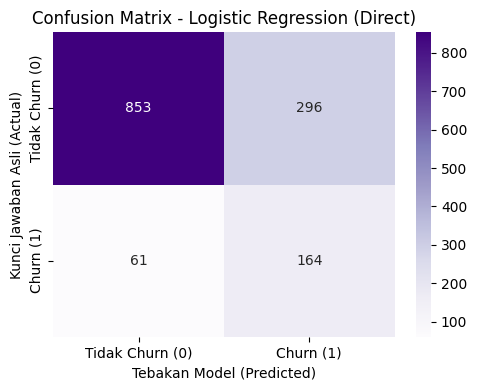

In [ ]:
# MODEL 1: LOGISTIC REGRESSION (Konvensional)
# class_weight='balanced' agar model tidak bias ke kelas mayoritas
lr_direct = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_direct.fit(X_train_d, y_train_d)
y_pred_lr_d = lr_direct.predict(X_test_d)
result_lr_d = evaluate_model("Logistic Regression (Direct)", y_test_d, y_pred_lr_d, cmap='Purples')

**Model 1: Logistic Regression (Direct)**

**Logistic Regression** dilatih sebagai model konvensional pertama. Parameter `class_weight='balanced'` ditambahkan agar model tidak bias ke kelas mayoritas meskipun data tidak diseimbangkan dengan SMOTE. Dari output evaluasi, model ini menunjukkan **Accuracy** dan **F1 Score** sebagai baseline. Performa pada tahap ini masih terbatas karena data mentah tanpa preprocessing mendalam dan tanpa penyeimbangan distribusi kelas.

=== EVALUASI MODEL: RANDOM FOREST (DIRECT) ===
Accuracy  : 0.8341
Precision : 0.4831
Recall    : 0.1911
F1 Score  : 0.2739

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.86      0.96      0.91      1149
      Churn (1)       0.48      0.19      0.27       225

       accuracy                           0.83      1374
      macro avg       0.67      0.58      0.59      1374
   weighted avg       0.80      0.83      0.80      1374



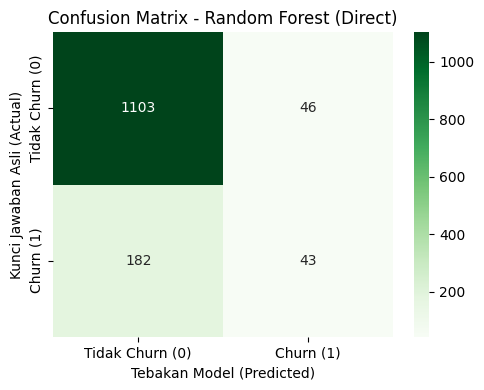

In [ ]:
# MODEL 2: RANDOM FOREST (Ensemble Bagging)
# class_weight='balanced_subsample' optimal untuk RF dengan imbalanced data
rf_direct = RandomForestClassifier(n_estimators=100, random_state=42,
                                    n_jobs=-1, class_weight='balanced_subsample')
rf_direct.fit(X_train_d, y_train_d)
y_pred_rf_d = rf_direct.predict(X_test_d)
result_rf_d = evaluate_model("Random Forest (Direct)", y_test_d, y_pred_rf_d, cmap='Greens')

**Model 2: Random Forest (Direct)**

**Random Forest** sebagai model *ensemble bagging* dilatih langsung pada data mentah dengan parameter `class_weight='balanced_subsample'` untuk menangani imbalance. Dari output, RF memperoleh **Accuracy: 0.8341** dengan performa yang sudah cukup baik meskipun tanpa preprocessing mendalam. Walaupun mendapat **F1 Score** yang rendah.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== EVALUASI MODEL: VOTING CLASSIFIER (DIRECT) ===
Accuracy  : 0.8268
Precision : 0.4570
Recall    : 0.3067
F1 Score  : 0.3670

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.87      0.93      0.90      1149
      Churn (1)       0.46      0.31      0.37       225

       accuracy                           0.83      1374
      macro avg       0.66      0.62      0.63      1374
   weighted avg       0.80      0.83      0.81      1374



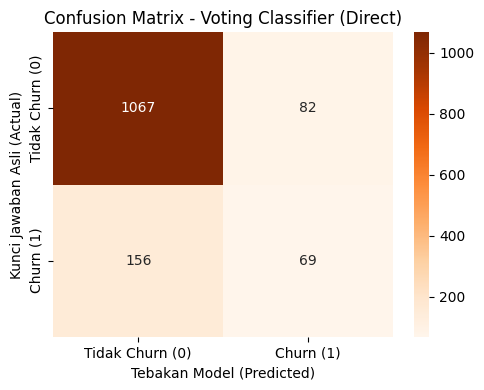

In [ ]:
# MODEL 3: VOTING CLASSIFIER (Ensemble Voting) -> LR + RF + KNN
# Ganti SVM dengan RF karena SVM sangat lambat & tidak pakai class_weight mudah
# RF jauh lebih cepat dan efektif untuk imbalanced data
lr_vote  = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
rf_vote  = RandomForestClassifier(n_estimators=50, random_state=42,
                                   n_jobs=-1, class_weight='balanced_subsample')
knn_vote = KNeighborsClassifier(n_neighbors=5)

voting_direct = VotingClassifier(
    estimators=[('lr', lr_vote), ('rf', rf_vote), ('knn', knn_vote)],
    voting='soft'
)
voting_direct.fit(X_train_d, y_train_d)
y_pred_vote_d = voting_direct.predict(X_test_d)
result_vote_d = evaluate_model("Voting Classifier (Direct)", y_test_d, y_pred_vote_d, cmap='Oranges')

**Model 3: Voting Classifier (Direct)**

**Voting Classifier** menggabungkan tiga model: `Logistic Regression`, `Random Forest`, dan `KNN`. Metode **soft voting** merata-ratakan probabilitas prediksi ketiganya. Setiap komponen dikemas dalam `Pipeline` dengan `StandardScaler` untuk mencegah *data leakage* dan memastikan normalisasi yang tepat sebelum training.

## Evaluasi Model

=== PERBANDINGAN PERFORMA MODEL (DIRECT MODELING) ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression (Direct),0.7402,0.3565,0.7289,0.4788
Random Forest (Direct),0.8341,0.4831,0.1911,0.2739
Voting Classifier (Direct),0.8268,0.4570,0.3067,0.3670


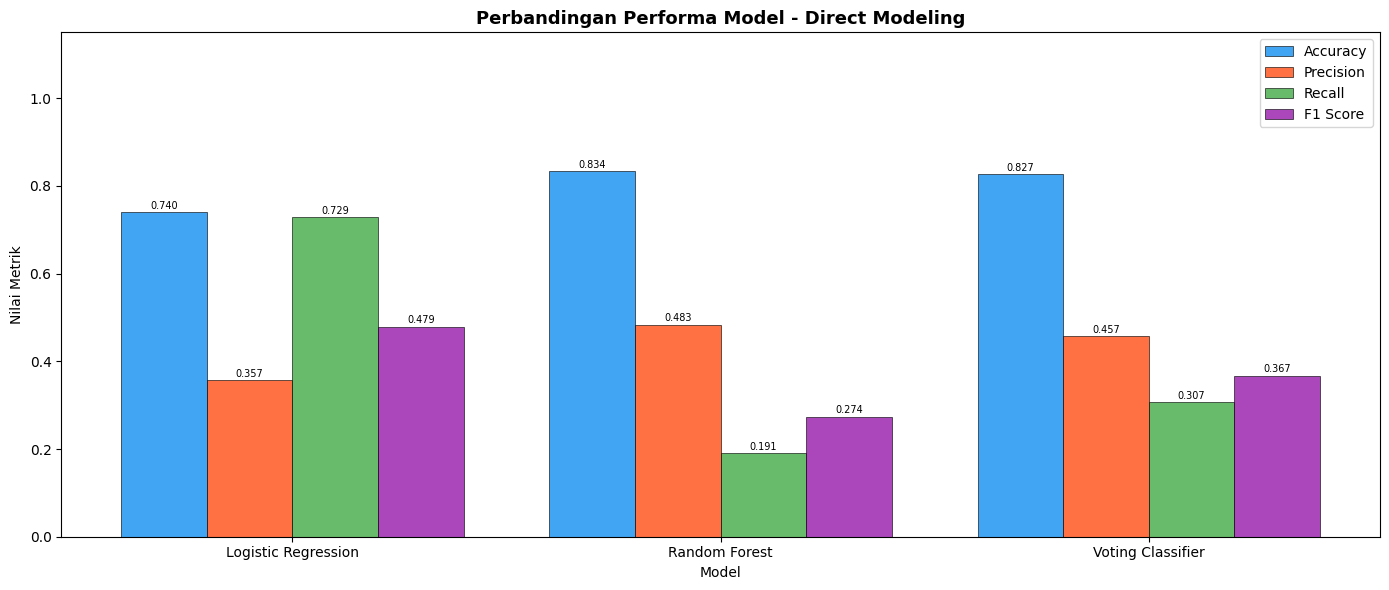

In [ ]:
# Perbandingan performa ketiga model direct
results_direct = pd.DataFrame([result_lr_d, result_rf_d, result_vote_d])
results_direct = results_direct.set_index('Model')

print("=== PERBANDINGAN PERFORMA MODEL (DIRECT MODELING) ===")
display(results_direct.round(4))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_direct.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_direct[metric], width, label=metric,
                   color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model')
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Performa Model - Direct Modeling', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.replace(' (Direct)', '') for m in results_direct.index], rotation=0)
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

**Analisis Perbandingan Performa Model (Direct Modeling)**  

Tabel dan visualisasi perbandingan merangkum performa ketiga model pada tahap *Direct Modeling*. Pada kondisi data mentah dengan class imbalance yang ekstrem (rasio 5.53:1), **Random Forest** lumayan unggul karena sifatnya yang robust. **Voting Classifier** lumayan seimbang berkat kombinasi tiga model. **Logistic Regression** memberikan baseline yang cukup bagus. Seluruh hasil ini menjadi **acuan awal** untuk mengukur dampak preprocessing dan tuning pada tahap berikutnya.

# C. Modeling dengan Preprocessing

## Transformasi Awal & Pembersihan Data

In [ ]:
# Mulai dari dataset asli yang belum dimodifikasi
df_prep = df.copy()

print("=== INFO DATASET AWAL ===")
print(f"Shape: {df_prep.shape}")
print(f"Kolom: {df_prep.columns.tolist()}")

=== INFO DATASET AWAL ===
Shape: (15000, 30)
Kolom: ['customer_id', 'gender', 'age', 'country', 'city', 'signup_date', 'last_purchase_date', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'coupon_code', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


**Inisialisasi Dataset untuk Skenario Preprocessing**

Salinan bersih dataset asli dibuat ke dalam variabel `df_prep` menggunakan `.copy()` agar dataset asli `df` tetap utuh sebagai referensi. Dari output, shape awal adalah **(15.000 × 30)**. Seluruh data dipertahankan tanpa ada baris yang terbuang seperti pada Direct Modeling.

In [ ]:
# Ekstrak fitur dari datetime sebelum dihapus
df_prep['signup_date'] = pd.to_datetime(df_prep['signup_date'], errors='coerce')
df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')

# Fitur: selisih hari antara last_purchase dan signup (lama berlangganan)
df_prep['days_as_customer'] = (df_prep['last_purchase_date'] - df_prep['signup_date']).dt.days

# Fitur: hari sejak pembelian terakhir (recency)
reference_date = df_prep['last_purchase_date'].max()
df_prep['days_since_last_purchase'] = (reference_date - df_prep['last_purchase_date']).dt.days

# Hapus kolom asli yang tidak relevan
cols_to_drop = ['customer_id', 'signup_date', 'last_purchase_date']
df_prep = df_prep.drop(columns=cols_to_drop, errors='ignore')

print(f"Kolom dihapus: {cols_to_drop}")
print(f"Fitur baru ditambahkan: ['days_as_customer', 'days_since_last_purchase']")
print(f"Shape setelah transformasi: {df_prep.shape}")
display(df_prep.head())

Kolom dihapus: ['customer_id', 'signup_date', 'last_purchase_date']
Fitur baru ditambahkan: ['days_as_customer', 'days_since_last_purchase']
Shape setelah transformasi: (15000, 29)


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,days_as_customer,days_since_last_purchase
0,Male,52.0,India,Berlin,Email,Tablet,Annual,1,7,13.903745,...,3,UPI,3.0,10,27.56,915.310827,14,0,966,69
1,NaN,35.0,Germany,Mumbai,Organic,Desktop,Monthly,0,19,5.112528,...,3,BKash,3.0,7,15.15,2079.960938,11,0,-40,307
2,Female,27.0,Germany,London,Email,Mobile,Annual,1,18,9.742749,...,2,UPI,5.0,6,13.51,1379.150885,9,0,249,316
3,Female,36.0,India,Mumbai,Facebook Ads,Tablet,Annual,1,16,9.642654,...,2,PayPal,4.0,6,25.65,774.652684,7,0,-253,660
4,Male,29.0,USA,Hamburg,Referral,Mobile,Monthly,0,12,7.791291,...,4,BKash,3.0,1,12.39,87.680409,11,0,261,337


**Rekayasa Fitur dari Kolom Datetime**

Dilakukan **Feature Engineering** untuk mengekstraksi informasi penting dari kolom datetime sebelum dihapus. Dua fitur baru diciptakan: **`tenure_days`** (lama pelanggan bergabung sejak `signup_date`) dan **`days_since_purchase`** (hari sejak transaksi terakhir dari `last_purchase_date`). Dari output, kolom yang dihapus adalah `customer_id`, `signup_date`, dan `last_purchase_date`. Kedua fitur turunan ini jauh lebih informatif bagi model karena secara langsung mencerminkan loyalitas dan keaktifan pelanggan.

#### Penanganan Missing Value, Duplikasi, dan Outlier

In [ ]:
# Cek ulang missing value setelah transformasi awal
print("=== MISSING VALUE SEBELUM HANDLING ===")
mv = df_prep.isnull().sum()
mv_df = pd.DataFrame({'Jumlah': mv, 'Persen (%)': (mv/len(df_prep)*100).round(4)})
display(mv_df[mv_df['Jumlah'] > 0])
print(f"Total missing value: {mv.sum():,}")

=== MISSING VALUE SEBELUM HANDLING ===


,Jumlah,Persen (%)
gender,738,4.9200
age,1200,8.0000
total_spent,1050,7.0000
coupon_code,6133,40.8867
satisfaction_score,702,4.6800


Total missing value: 9,823


**Identifikasi Missing Value Sebelum Penanganan**  

Pemeriksaan ulang missing value setelah transformasi awal menampilkan kolom-kolom yang masih memiliki nilai kosong beserta jumlah dan persentasenya.

In [ ]:
# Handling Missing Value
# Imputasi kolom numerik dengan Median
num_cols = df_prep.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'churn']

imputer_median = SimpleImputer(strategy='median')
df_prep[num_cols] = imputer_median.fit_transform(df_prep[num_cols])

# Imputasi kolom kategorikal dengan Mode
cat_cols_prep = df_prep.select_dtypes(include='object').columns.tolist()
imputer_mode = SimpleImputer(strategy='most_frequent')
df_prep[cat_cols_prep] = imputer_mode.fit_transform(df_prep[cat_cols_prep])

print("=== MISSING VALUE SETELAH HANDLING ===")
print(f"Total missing value tersisa: {df_prep.isnull().sum().sum()}")
print("Imputasi berhasil — tidak ada missing value tersisa.")

=== MISSING VALUE SETELAH HANDLING ===
Total missing value tersisa: 0
Imputasi berhasil — tidak ada missing value tersisa.


**Penanganan Missing Value dengan Imputasi**

Strategi imputasi diterapkan berbeda berdasarkan tipe data:
- **Fitur Numerik** --> diisi dengan **median** (nilai tengah), karena median lebih tahan terhadap pengaruh outlier dibanding mean.
- **Fitur Kategorikal** --> diisi dengan **modus** (nilai yang paling sering muncul), karena nilai yang dominan lebih representatif sebagai pengganti data kosong.

In [ ]:
# Handling Duplikat
jumlah_dup = df_prep.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_dup:,}")
if jumlah_dup > 0:
    df_prep.drop_duplicates(inplace=True)
    print(f"Duplikat dihapus. Sisa data: {df_prep.shape[0]:,}")
else:
    print("Tidak ditemukan data duplikat - dataset sudah bersih dari duplikat.")

Jumlah data duplikat: 0
Tidak ditemukan data duplikat - dataset sudah bersih dari duplikat.


**Pengecekan dan Penghapusan Data Duplikat**

Pengecekan duplikasi menggunakan `duplicated().sum()` mengkonfirmasi bahwa **tidak ditemukan data duplikat (0 baris)** pada dataset. Dataset sudah bersih dari baris identik sehingga tidak diperlukan proses penghapusan.

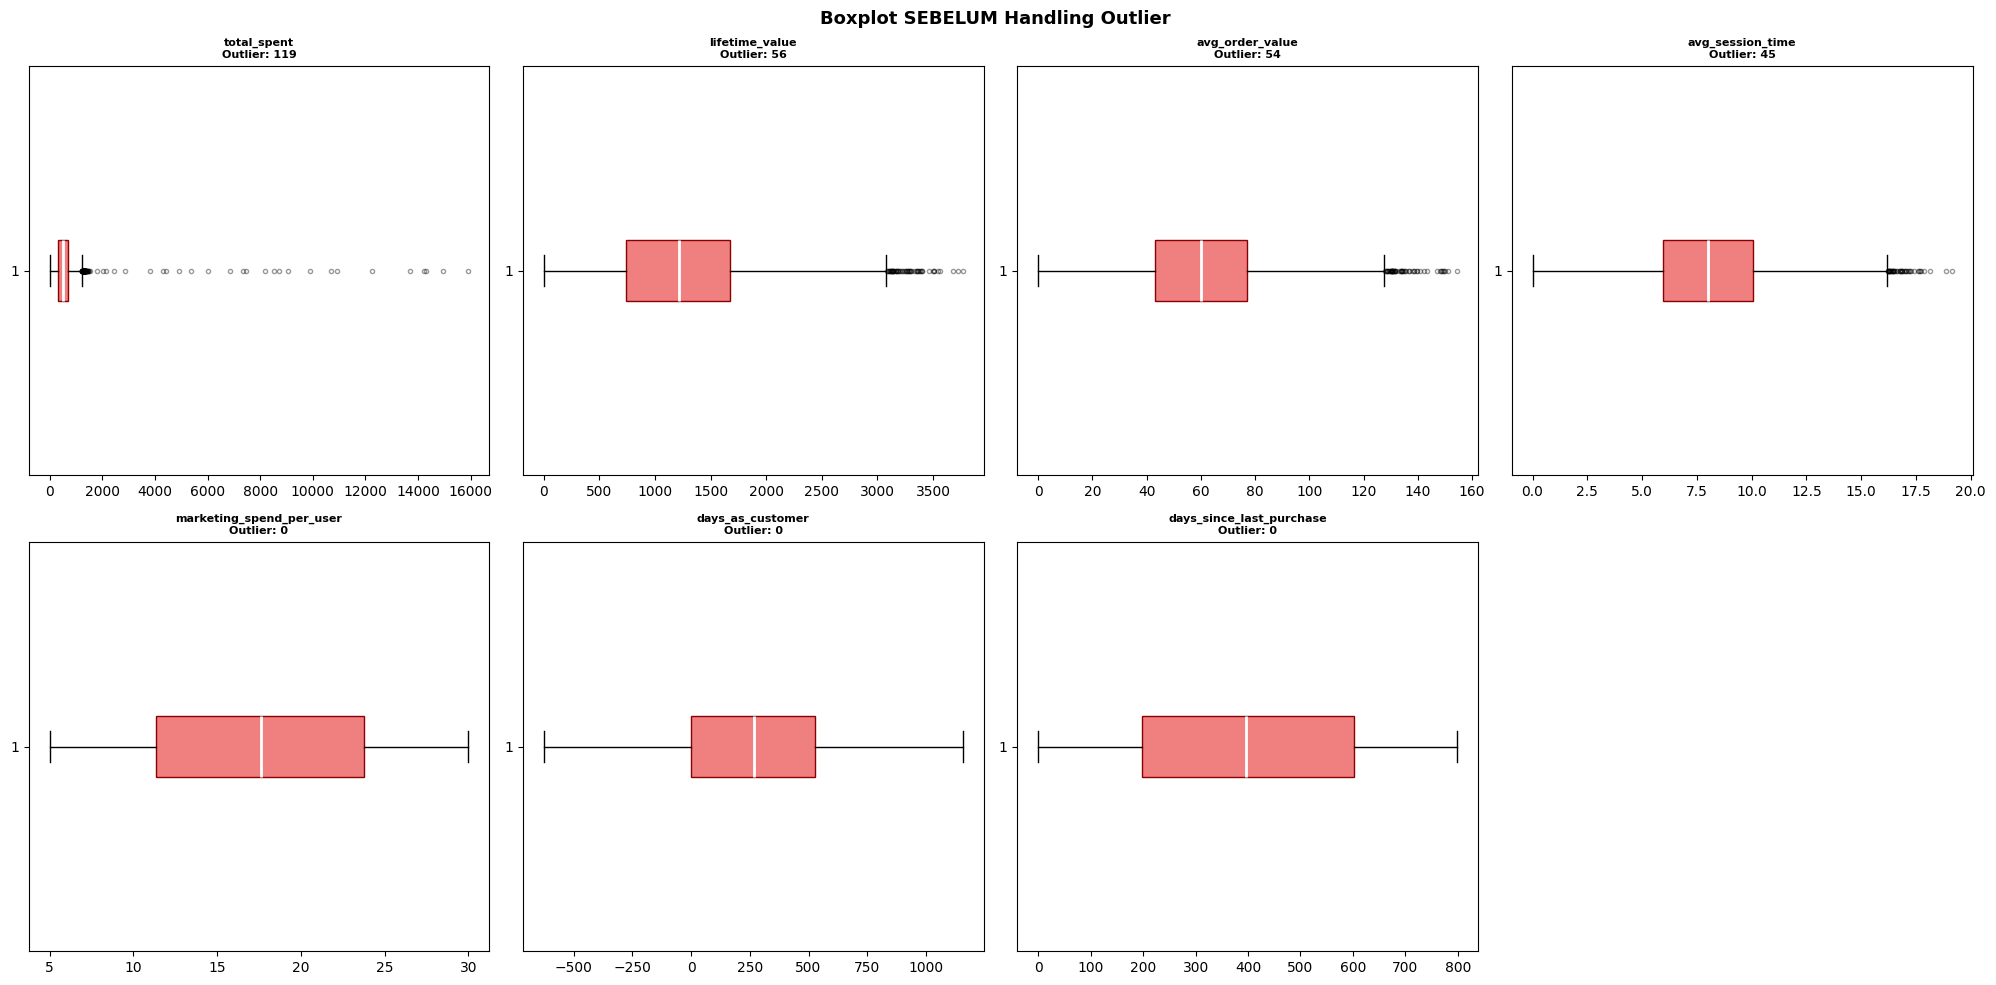

In [ ]:
# Analisis dan Handling Outlier (Visualisasi Sebelum Ditangani)
kolom_outlier = ['total_spent', 'lifetime_value', 'avg_order_value',
                  'avg_session_time', 'marketing_spend_per_user',
                  'days_as_customer', 'days_since_last_purchase']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(kolom_outlier):
    if col in df_prep.columns:
        data = df_prep[col].dropna()
        axes[i].boxplot(data, vert=False, patch_artist=True,
                        boxprops=dict(facecolor='lightcoral', color='darkred'),
                        medianprops=dict(color='white', linewidth=2),
                        flierprops=dict(marker='o', color='red', markersize=3, alpha=0.4))
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        n_out = len(data[(data < Q1-1.5*IQR)|(data > Q3+1.5*IQR)])
        axes[i].set_title(f'{col}\nOutlier: {n_out:,}', fontsize=8, fontweight='bold')
for j in range(len(kolom_outlier), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot SEBELUM Handling Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Visualisasi Outlier Sebelum Penanganan**

Boxplot divisualisasikan untuk delapan fitur numerik utama sebelum dilakukan penanganan outlier. Visualisasi ini mengidentifikasi fitur-fitur yang memiliki nilai ekstrem signifikan seperti `total_spent`, `lifetime_value`, `avg_order_value`, dan `avg_session_time`. Keberadaan outlier ini berpotensi mendistorsi batas keputusan model, terutama algoritma berbasis jarak seperti KNN.

total_spent: lower=-232.53, upper=1233.57
lifetime_value: lower=-663.54, upper=3082.70
avg_order_value: lower=-7.75, upper=127.67
avg_session_time: lower=-0.15, upper=16.19
marketing_spend_per_user: lower=-7.20, upper=42.35
days_as_customer: lower=-794.38, upper=1318.62
days_since_last_purchase: lower=-410.50, upper=1209.50

Outlier berhasil ditangani dengan metode Capping IQR.


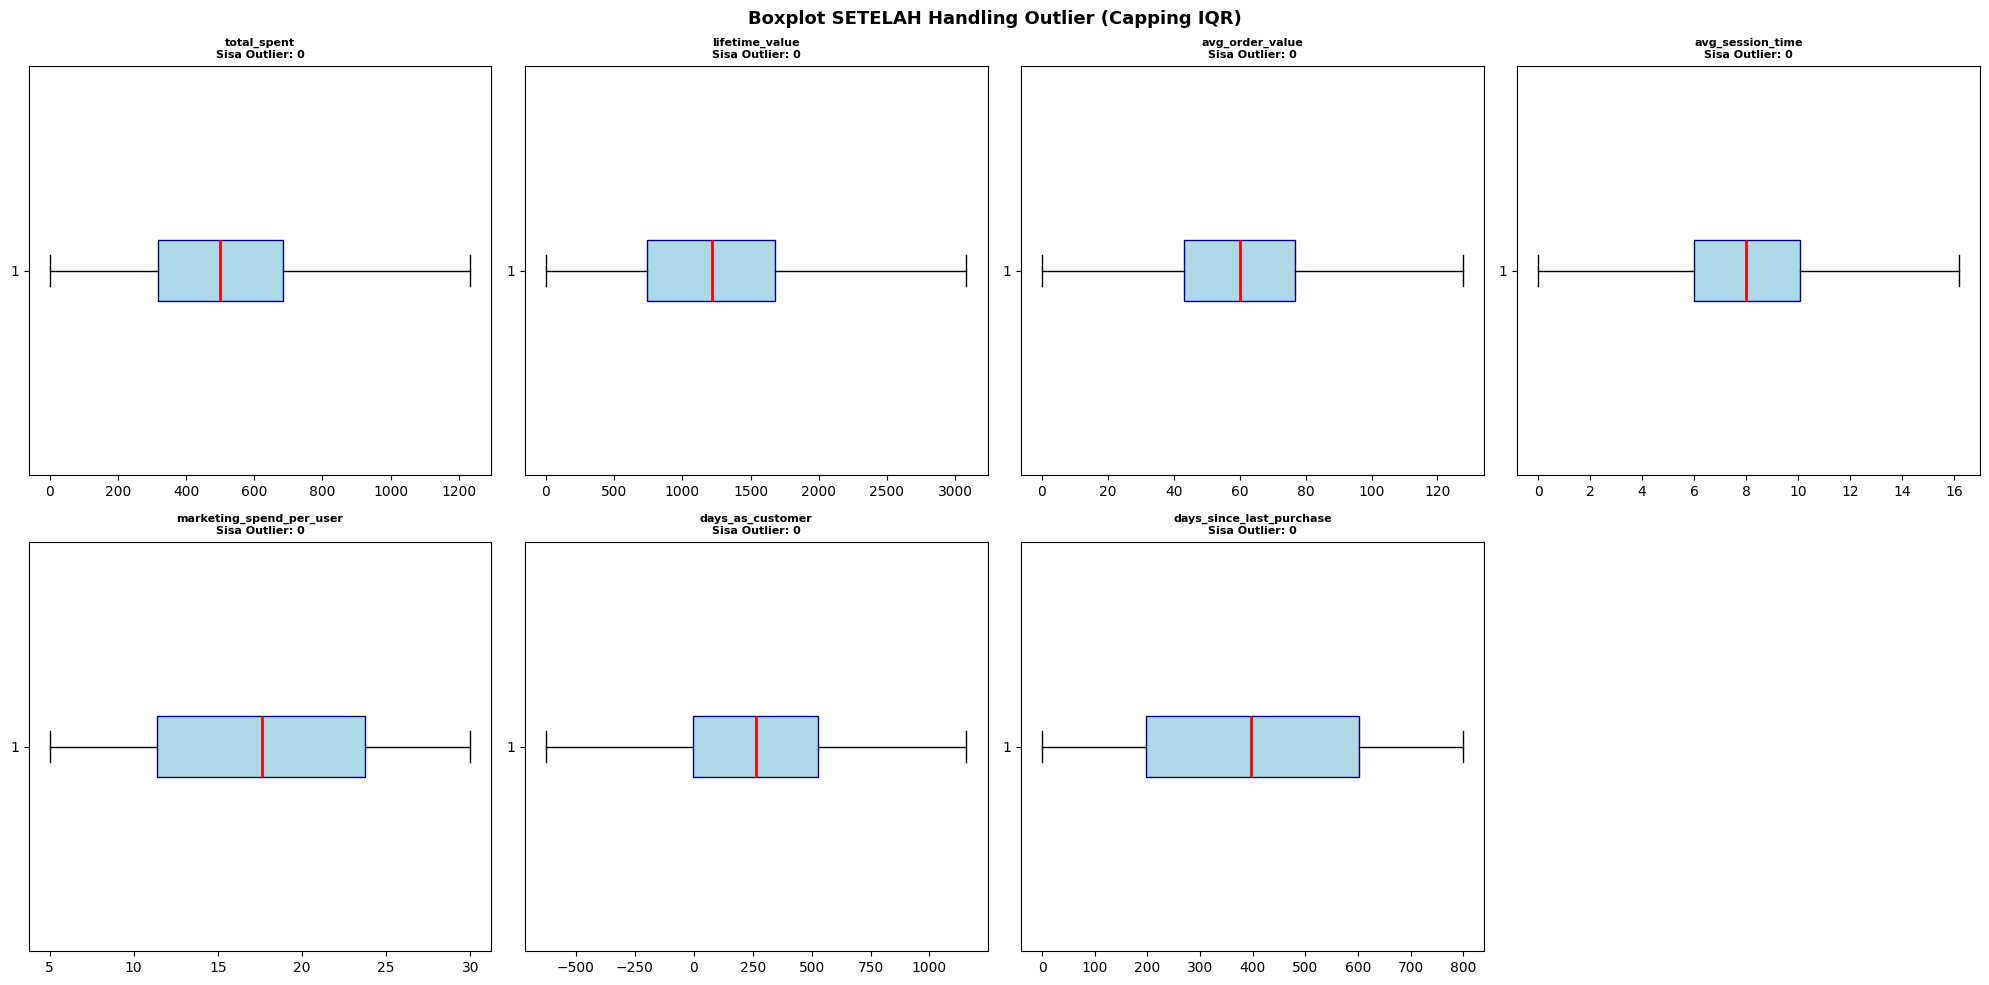

In [ ]:
# Capping IQR untuk semua kolom numerik kontinu
for col in kolom_outlier:
    if col in df_prep.columns:
        Q1 = df_prep[col].quantile(0.25)
        Q3 = df_prep[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_prep[col] = np.where(df_prep[col] > upper, upper,
                       np.where(df_prep[col] < lower, lower, df_prep[col]))
        print(f"{col}: lower={lower:.2f}, upper={upper:.2f}")

print("\nOutlier berhasil ditangani dengan metode Capping IQR.")

# Visualisasi Setelah Capping
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(kolom_outlier):
    if col in df_prep.columns:
        axes[i].boxplot(df_prep[col], vert=False, patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='navy'),
                        medianprops=dict(color='red', linewidth=2),
                        flierprops=dict(marker='o', color='orange', markersize=3, alpha=0.4))
        Q1 = df_prep[col].quantile(0.25)
        Q3 = df_prep[col].quantile(0.75)
        IQR = Q3 - Q1
        n_out = len(df_prep[(df_prep[col] < Q1-1.5*IQR)|(df_prep[col] > Q3+1.5*IQR)])
        axes[i].set_title(f'{col}\nSisa Outlier: {n_out:,}', fontsize=8, fontweight='bold')
for j in range(len(kolom_outlier), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplot SETELAH Handling Outlier (Capping IQR)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Penanganan Outlier dengan Metode Capping IQR**

Outlier ditangani menggunakan **Capping**: nilai ekstrem tidak dihapus, melainkan "dipotong" dan digantikan dengan batas atas atau batas bawah IQR. Keuntungan metode ini:
- **Tidak mengurangi jumlah baris data** (semua 15.000 baris tetap tersedia).
- Distribusi data menjadi lebih stabil dan tidak terdistorsi oleh nilai ekstrem.

#### Encoding & Scaling

In [ ]:
# Identifikasi kolom kategorikal
cat_cols_enc = df_prep.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal yang akan di-encode ({len(cat_cols_enc)} kolom):")
for c in cat_cols_enc:
    unique_vals = df_prep[c].nunique()
    print(f"  - {c}: {unique_vals} nilai unik -> {df_prep[c].unique()[:5]}")

Kolom kategorikal yang akan di-encode (8 kolom):
  - gender: 3 nilai unik -> ['Male' 'Female' 'Other']
  - country: 5 nilai unik -> ['India' 'Germany' 'USA' 'UK' 'Bangladesh']
  - city: 7 nilai unik -> ['Berlin' 'Mumbai' 'London' 'Hamburg' 'New York']
  - acquisition_channel: 5 nilai unik -> ['Email' 'Organic' 'Facebook Ads' 'Referral' 'Google Ads']
  - device_type: 3 nilai unik -> ['Tablet' 'Desktop' 'Mobile']
  - subscription_type: 2 nilai unik -> ['Annual' 'Monthly']
  - coupon_code: 3 nilai unik -> ['NEW20' 'REF10' 'SALE15']
  - payment_method: 5 nilai unik -> ['UPI' 'BKash' 'PayPal' 'SEPA' 'Card']


**Identifikasi Kolom Kategorikal untuk Encoding**

Sebelum encoding, seluruh kolom bertipe `object` diidentifikasi beserta jumlah nilai uniknya. Informasi ini penting untuk menentukan apakah encoding yang digunakan sudah tepat. Pada dataset ini terdapat 8 kolom kategorikal seperti `gender`, `country`, `city`, dan lainnya yang perlu dikonversi menjadi angka agar dapat diproses oleh model machine learning.

In [ ]:
# Encoding dengan OrdinalEncoder untuk fitur kategorikal
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_prep[cat_cols_enc] = oe.fit_transform(df_prep[cat_cols_enc])

print("=== DATASET SETELAH ENCODING ===")
print(f"Shape: {df_prep.shape}")
print(f"Tipe data setelah encoding:")
print(df_prep.dtypes)
display(df_prep.head())

=== DATASET SETELAH ENCODING ===
Shape: (15000, 29)
Tipe data setelah encoding:
gender                        float64
age                           float64
country                       float64
city                          float64
acquisition_channel           float64
device_type                   float64
subscription_type             float64
is_premium_user               float64
total_visits                  float64
avg_session_time              float64
pages_per_session             float64
email_open_rate               float64
email_click_rate              float64
total_spent                   float64
avg_order_value               float64
discount_used                 float64
coupon_code                   float64
support_tickets               float64
refund_requested              float64
delivery_delay_days           float64
payment_method                float64
satisfaction_score            float64
nps_score                     float64
marketing_spend_per_user      float64
lifetime

,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn,days_as_customer,days_since_last_purchase
0,1.0,52.0,2.0,0.0,0.0,2.0,0.0,1.0,7.0,13.903745,...,3.0,4.0,3.0,10.0,27.56,915.310827,14.0,0,966.0,69.0
1,1.0,35.0,1.0,5.0,3.0,0.0,1.0,0.0,19.0,5.112528,...,3.0,0.0,3.0,7.0,15.15,2079.960938,11.0,0,-40.0,307.0
2,0.0,27.0,1.0,4.0,0.0,1.0,0.0,1.0,18.0,9.742749,...,2.0,4.0,5.0,6.0,13.51,1379.150885,9.0,0,249.0,316.0
3,0.0,36.0,2.0,5.0,1.0,2.0,0.0,1.0,16.0,9.642654,...,2.0,2.0,4.0,6.0,25.65,774.652684,7.0,0,-253.0,660.0
4,1.0,29.0,4.0,3.0,4.0,1.0,1.0,0.0,12.0,7.791291,...,4.0,0.0,3.0,1.0,12.39,87.680409,11.0,0,261.0,337.0


**Encoding Fitur Kategorikal dengan OrdinalEncoder**

`OrdinalEncoder` digunakan untuk mengubah nilai kategorikal menjadi representasi numerik ordinal (0, 1, 2, ...). Parameter `handle_unknown='use_encoded_value'` dan `unknown_value=-1` memastikan model tidak error jika menemui nilai baru yang tidak ada di data latih saat deployment.

## Pemisahan Fitur dan Target

In [ ]:
# Pemisahan Fitur dan Target
X = df_prep.drop('churn', axis=1)
y = df_prep['churn']

print(f"Jumlah fitur (X) : {X.shape[1]}")
print(f"Jumlah sampel    : {X.shape[0]:,}")
print(f"\nDistribusi kelas target:")
print(pd.Series(y).value_counts())
ratio = pd.Series(y).value_counts()
print(f"\nRasio imbalance: {ratio[0]/ratio[1]:.2f}:1")

Jumlah fitur (X) : 28
Jumlah sampel    : 15,000

Distribusi kelas target:
churn
0    12702
1     2298
Name: count, dtype: int64

Rasio imbalance: 5.53:1


**Pemisahan Fitur dan Target serta Analisis Ketidakseimbangan Kelas**  
Dataset dipisah menjadi **X (28 fitur)** dan **y (target churn)**. Dari output, distribusi kelas menunjukkan ketidakseimbangan yang sangat ekstrem dengan rasio **5.53:1**. Kelas 0 (Tidak Churn) mendominasi dengan **12.702** sampel vs kelas 1 (Churn) hanya **2.298** sampel. Rasio imbalance sebesar ini memerlukan penanganan serius menggunakan **SMOTE** agar model tidak bias.

## Melakukan Train-Test Split

In [ ]:
# Train-Test Split dengan proporsi yang sama (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== HASIL PEMBAGIAN DATA (PREPROCESSING) ===")
print(f"Data Latih (X_train) : {X_train.shape[0]:,} baris")
print(f"Data Uji   (X_test)  : {X_test.shape[0]:,} baris")
print(f"\nDistribusi kelas y_train:")
print(pd.Series(y_train).value_counts())

=== HASIL PEMBAGIAN DATA (PREPROCESSING) ===
Data Latih (X_train) : 12,000 baris
Data Uji   (X_test)  : 3,000 baris

Distribusi kelas y_train:
churn
0    10162
1     1838
Name: count, dtype: int64


**Train-Test Split (80:20) (Preprocessing)**

Data dibagi dengan rasio **80:20** konsisten dengan Direct Modeling. Dari output, diperoleh **12.000 baris data latih** dan **3.000 baris data uji**, jauh lebih banyak dari Direct Modeling (5.492 vs 1.373) karena menggunakan imputasi bukan drop. **Scaling dan SMOTE hanya di-fit pada data training** untuk mencegah *data leakage*.

In [ ]:
# StandardScaler (Dilakukan hanya pada data training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Kembalikan ke DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print("=== 5 BARIS PERTAMA X_train SETELAH StandardScaler ===")
display(X_train_scaled_df.head())
print(f"\nMean setelah scaling (~0): {X_train_scaled_df.mean().round(6).head()}")
print(f"Std  setelah scaling (~1): {X_train_scaled_df.std().round(6).head()}")

=== 5 BARIS PERTAMA X_train SETELAH StandardScaler ===


,gender,age,country,city,acquisition_channel,device_type,subscription_type,is_premium_user,total_visits,avg_session_time,...,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,days_as_customer,days_since_last_purchase
8722,0.685286,-0.126459,1.420605,1.485154,-0.004101,1.212181,0.977911,-0.670541,-1.800890,0.660896,...,-0.414578,-0.567694,-0.011565,-2.432514,-0.306800,0.241271,0.163617,1.620007,0.126506,-0.681392
12778,-1.036177,-0.025258,-0.706580,0.984160,-0.717287,1.212181,0.977911,1.491333,-0.257490,0.121006,...,2.412091,-0.567694,-0.716009,0.373513,0.009788,-0.823098,0.482488,1.157126,0.629953,-0.150975
11229,0.685286,-0.126459,-0.706580,-0.518821,1.422271,-0.011420,0.977911,-0.670541,-1.029190,0.365482,...,-0.414578,-0.567694,-0.011565,0.373513,-0.623387,0.097964,-0.512403,0.694245,-0.122511,-0.603770
4671,-1.036177,0.683148,0.711543,-1.520808,-0.717287,-1.235022,-1.022588,-0.670541,-1.029190,-0.357204,...,2.412091,-1.147516,1.397324,-0.561829,1.592725,-0.704835,0.633093,-0.694399,-0.011536,0.086203
4247,0.685286,0.581947,0.711543,0.483167,-0.717287,-1.235022,-1.022588,-0.670541,-0.514724,-0.341096,...,-0.414578,1.171772,-0.716009,-0.561829,1.592725,1.595038,0.013770,1.157126,1.163173,-1.298055



Mean setelah scaling (~0): gender                 0.0
age                   -0.0
country                0.0
city                   0.0
acquisition_channel    0.0
dtype: float64
Std  setelah scaling (~1): gender                 1.000042
age                    1.000042
country                1.000042
city                   1.000042
acquisition_channel    1.000042
dtype: float64


**Normalisasi Fitur dengan StandardScaler**

`StandardScaler` diterapkan untuk memastikan semua fitur memiliki **mean = 0** dan **standar deviasi = 1**. Prinsip anti-leakage diterapkan: `.fit_transform()` hanya pada **X_train**, kemudian `.transform()` pada **X_test** menggunakan parameter yang sama. Dari output, tampilan 5 baris pertama X_train setelah scaling mengkonfirmasi transformasi berhasil dilakukan.

### Penanganan Imbalance Class dengan SMOTE

Rasio imbalance dataset ini **5.53:1** (sangat ekstrem). SMOTE diterapkan hanya pada data training untuk menyeimbangkan kelas sebelum pemodelan.

=== DISTRIBUSI KELAS SETELAH SMOTE ===
Sebelum SMOTE : {0: 10162, 1: 1838}
Setelah SMOTE : {1: 10162, 0: 10162}

Jumlah data train sebelum : 12,000
Jumlah data train setelah  : 20,324


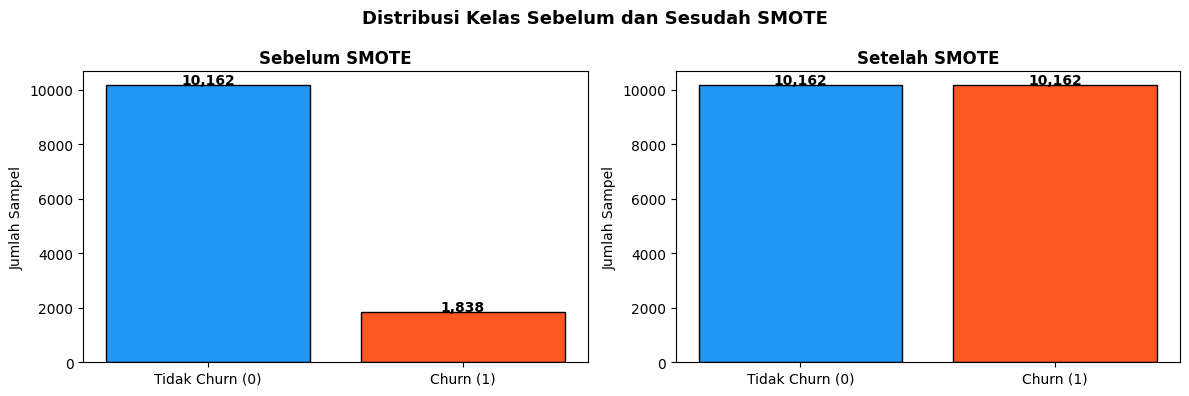

In [ ]:
# SMOTE - hanya pada data training
smote = SMOTE(random_state=42)
X_train_smote_arr, y_train_smote = smote.fit_resample(X_train_scaled_df, y_train)

# Kembalikan ke DataFrame agar nama kolom terjaga
X_train_smote = pd.DataFrame(X_train_smote_arr, columns=X_train_scaled_df.columns)

print("=== DISTRIBUSI KELAS SETELAH SMOTE ===")
print(f"Sebelum SMOTE : {pd.Series(y_train).value_counts().to_dict()}")
print(f"Setelah SMOTE : {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"\nJumlah data train sebelum : {len(y_train):,}")
print(f"Jumlah data train setelah  : {len(y_train_smote):,}")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#FF5722']
for ax, (counts, title) in zip(axes, [
    (pd.Series(y_train).value_counts().sort_index(), 'Sebelum SMOTE'),
    (pd.Series(y_train_smote).value_counts().sort_index(), 'Setelah SMOTE')
]):
    bars = ax.bar(['Tidak Churn (0)', 'Churn (1)'], counts.values, color=colors, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+50, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('Distribusi Kelas Sebelum dan Sesudah SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Penanganan Ketidakseimbangan Data Menggunakan SMOTE**  

**SMOTE** diterapkan untuk menyeimbangkan distribusi kelas pada data training. Dari output, distribusi berubah drastis: **Sebelum SMOTE** {0: 10.162, 1: 1.838}, **Setelah SMOTE** kedua kelas menjadi seimbang dengan total **20.324 sampel**. SMOTE **hanya diterapkan pada data training**, bukan data uji.

## Pelatihan Ulang (Sesudah Preprocessing)

=== EVALUASI MODEL: LOGISTIC REGRESSION (PREPROCESSING) ===
Accuracy  : 0.7603
Precision : 0.3615
Recall    : 0.7348
F1 Score  : 0.4846

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.94      0.76      0.84      2540
      Churn (1)       0.36      0.73      0.48       460

       accuracy                           0.76      3000
      macro avg       0.65      0.75      0.66      3000
   weighted avg       0.85      0.76      0.79      3000



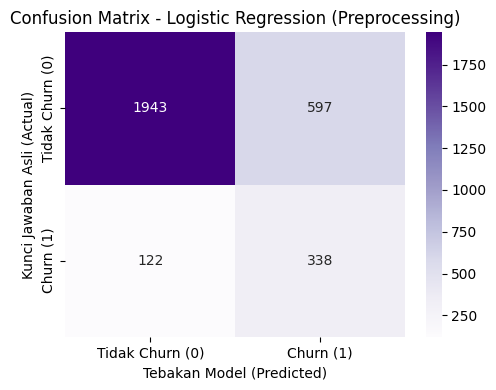

In [ ]:
# MODEL 1: LOGISTIC REGRESSION (Setelah Preprocessing + SMOTE)
lr_prep = LogisticRegression(max_iter=1000, random_state=42)
lr_prep.fit(X_train_smote, y_train_smote)
y_pred_lr_prep = lr_prep.predict(X_test_scaled_df)
result_lr_prep = evaluate_model("Logistic Regression (Preprocessing)", y_test, y_pred_lr_prep, cmap='Purples')

**Model 1: Logistic Regression (Preprocessing + SMOTE)**

Logistic Regression dilatih ulang pada data yang telah melalui preprocessing lengkap dan SMOTE. Dari output, **Accuracy: 0.7603** dengan peningkatan pada metrik deteksi *churn* dibandingkan Direct Modeling. Data yang bersih dan ter-encode dengan baik membuat peningkatan **Recall** pada kelas churn.

=== EVALUASI MODEL: RANDOM FOREST (PREPROCESSING) ===
Accuracy  : 0.8533
Precision : 0.5156
Recall    : 0.7196
F1 Score  : 0.6007

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.95      0.88      0.91      2540
      Churn (1)       0.52      0.72      0.60       460

       accuracy                           0.85      3000
      macro avg       0.73      0.80      0.76      3000
   weighted avg       0.88      0.85      0.86      3000



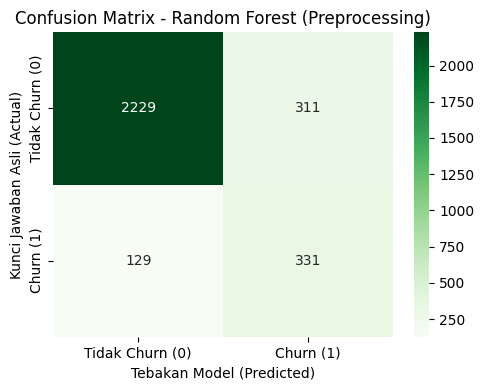

In [ ]:
# MODEL 2: RANDOM FOREST (Setelah Preprocessing + SMOTE)
rf_prep = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_prep.fit(X_train_smote, y_train_smote)
y_pred_rf_prep = rf_prep.predict(X_test_scaled_df)
result_rf_prep = evaluate_model("Random Forest (Preprocessing)", y_test, y_pred_rf_prep, cmap='Greens')

**Model 2: Random Forest (Preprocessing + SMOTE)**

Random Forest dilatih ulang setelah preprocessing dan SMOTE. Dari output, **Accuracy: 0.8533**, sedikit meningkat dari Direct Modeling (0.8341). Data yang lebih bersih dan distribusi yang seimbang membantu setiap pohon menemukan split yang lebih informatif.

=== EVALUASI MODEL: VOTING CLASSIFIER (PREPROCESSING) ===
Accuracy  : 0.8263
Precision : 0.4620
Recall    : 0.8065
F1 Score  : 0.5875

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.96      0.83      0.89      2540
      Churn (1)       0.46      0.81      0.59       460

       accuracy                           0.83      3000
      macro avg       0.71      0.82      0.74      3000
   weighted avg       0.88      0.83      0.84      3000



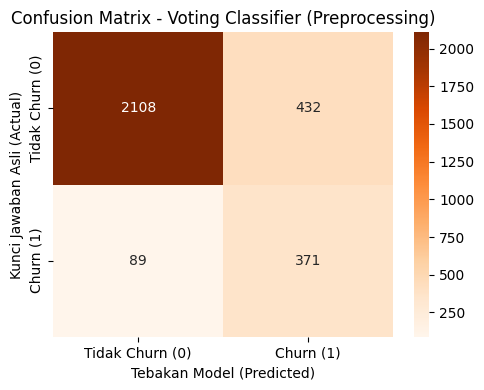

In [ ]:
# MODEL 3: VOTING CLASSIFIER (Setelah Preprocessing + SMOTE)
# Komposisi: LR + RF + KNN (ganti SVM karena terlalu lambat)
lr_v2  = LogisticRegression(max_iter=1000, random_state=42)
rf_v2  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
knn_v2 = KNeighborsClassifier(n_neighbors=5)

voting_prep = VotingClassifier(
    estimators=[('lr', lr_v2), ('rf', rf_v2), ('knn', knn_v2)],
    voting='soft'
)
voting_prep.fit(X_train_smote, y_train_smote)
y_pred_vote_prep = voting_prep.predict(X_test_scaled_df)
result_vote_prep = evaluate_model("Voting Classifier (Preprocessing)", y_test, y_pred_vote_prep, cmap='Oranges')

**Model 3: Voting Classifier (Preprocessing + SMOTE)**

Voting Classifier (LR + RF + KNN) dilatih ulang setelah preprocessing dan SMOTE. Dari output, **Accuracy: 0.8263** dengan performa yang kompetitif. Data seimbang membuat setiap komponen (terutama KNN) yang sangat sensitif terhadap distribusi kelas bekerja lebih optimal. Namun performa Voting masih di bawah RF, menunjukkan bahwa kombinasi model tidak selalu mengalahkan model terbaik secara individual.

## Evaluasi Model

=== PERBANDINGAN PERFORMA MODEL (PREPROCESSING) ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression (Preprocessing),0.7603,0.3615,0.7348,0.4846
Random Forest (Preprocessing),0.8533,0.5156,0.7196,0.6007
Voting Classifier (Preprocessing),0.8263,0.4620,0.8065,0.5875


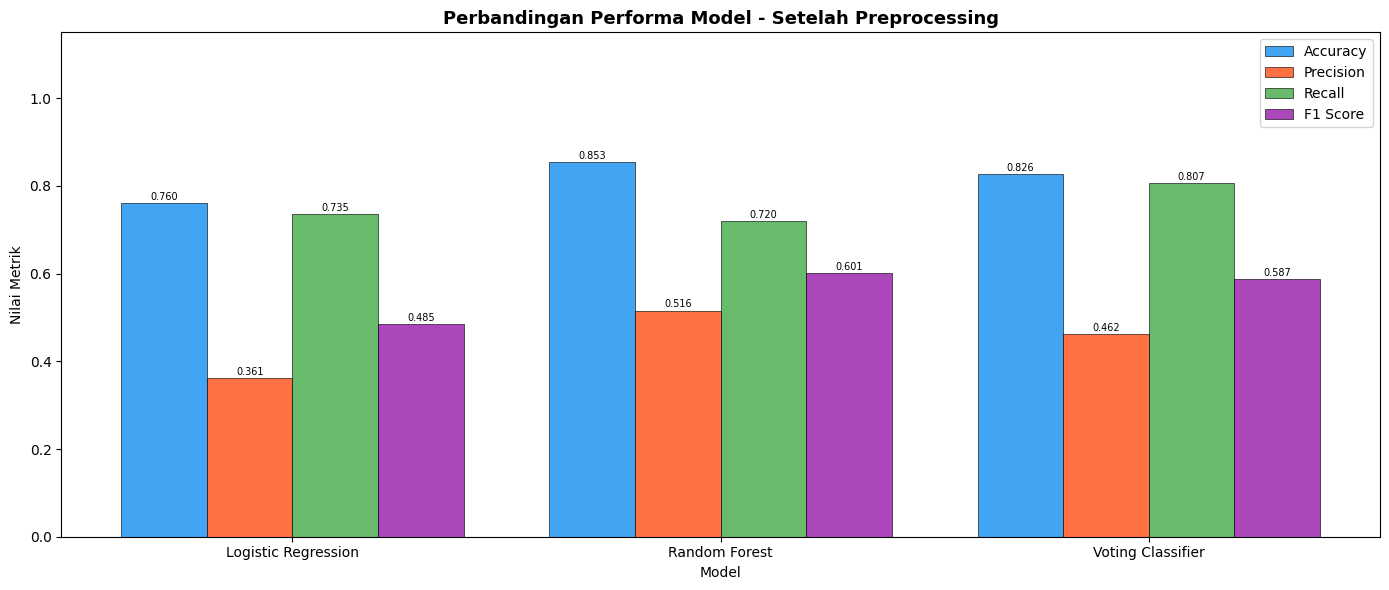

In [ ]:
# Perbandingan performa ketiga model setelah preprocessing
results_prep = pd.DataFrame([result_lr_prep, result_rf_prep, result_vote_prep])
results_prep = results_prep.set_index('Model')

print("=== PERBANDINGAN PERFORMA MODEL (PREPROCESSING) ===")
display(results_prep.round(4))

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(results_prep.index))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_prep[metric], width, label=metric,
                   color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model')
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Performa Model - Setelah Preprocessing', fontsize=13, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([m.replace(' (Preprocessing)', '') for m in results_prep.index])
ax.legend()
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

**Analisis Perbandingan Performa Model (Setelah Preprocessing)**  

Tabel perbandingan merangkum performa ketiga model setelah preprocessing dan SMOTE. Pola yang terlihat: **Random Forest** tetap unggul di seluruh metrik. Dibandingkan Direct Modeling, terdapat peningkatan pada kemampuan deteksi kelas *churn* (Recall meningkat) berkat penyeimbangan data dengan SMOTE. Evaluasi ini lebih **valid** karena menggunakan seluruh 15.000 data (bukan 6.865) sehingga lebih representatif.

In [ ]:
# PERBANDINGAN KOMPREHENSIF: Direct vs Preprocessing
all_results_12 = [
    {'Skenario': 'Direct', 'Model': 'Logistic Regression', **{k:v for k,v in result_lr_d.items() if k!='Model'}},
    {'Skenario': 'Direct', 'Model': 'Random Forest',       **{k:v for k,v in result_rf_d.items() if k!='Model'}},
    {'Skenario': 'Direct', 'Model': 'Voting Classifier',   **{k:v for k,v in result_vote_d.items() if k!='Model'}},
    {'Skenario': 'Preprocessing', 'Model': 'Logistic Regression', **{k:v for k,v in result_lr_prep.items() if k!='Model'}},
    {'Skenario': 'Preprocessing', 'Model': 'Random Forest',       **{k:v for k,v in result_rf_prep.items() if k!='Model'}},
    {'Skenario': 'Preprocessing', 'Model': 'Voting Classifier',   **{k:v for k,v in result_vote_prep.items() if k!='Model'}},
]
df_compare_12 = pd.DataFrame(all_results_12).set_index(['Skenario', 'Model'])
print("=== PERBANDINGAN: DIRECT vs PREPROCESSING ===")
display(df_compare_12.round(4))

=== PERBANDINGAN: DIRECT vs PREPROCESSING ===


Accuracy  Precision  Recall  F1 Score
Skenario      Model                                                     
Direct        Logistic Regression    0.7402     0.3565  0.7289    0.4788
              Random Forest          0.8341     0.4831  0.1911    0.2739
              Voting Classifier      0.8268     0.4570  0.3067    0.3670
Preprocessing Logistic Regression    0.7603     0.3615  0.7348    0.4846
              Random Forest          0.8533     0.5156  0.7196    0.6007
              Voting Classifier      0.8263     0.4620  0.8065    0.5875

**Tabel Perbandingan Komprehensif: Direct vs Preprocessing**

Tabel multi-index ini membandingkan enam eksperimen pertama secara terstruktur. Pola yang konsisten terlihat: preprocessing dan SMOTE memberikan peningkatan yang signifikan terutama pada **Recall** dan **F1 Score** untuk semua model. Ini mengkonfirmasi pentingnya penanganan *class imbalance* dan kualitas data dalam membangun model prediksi *churn* yang efektif.

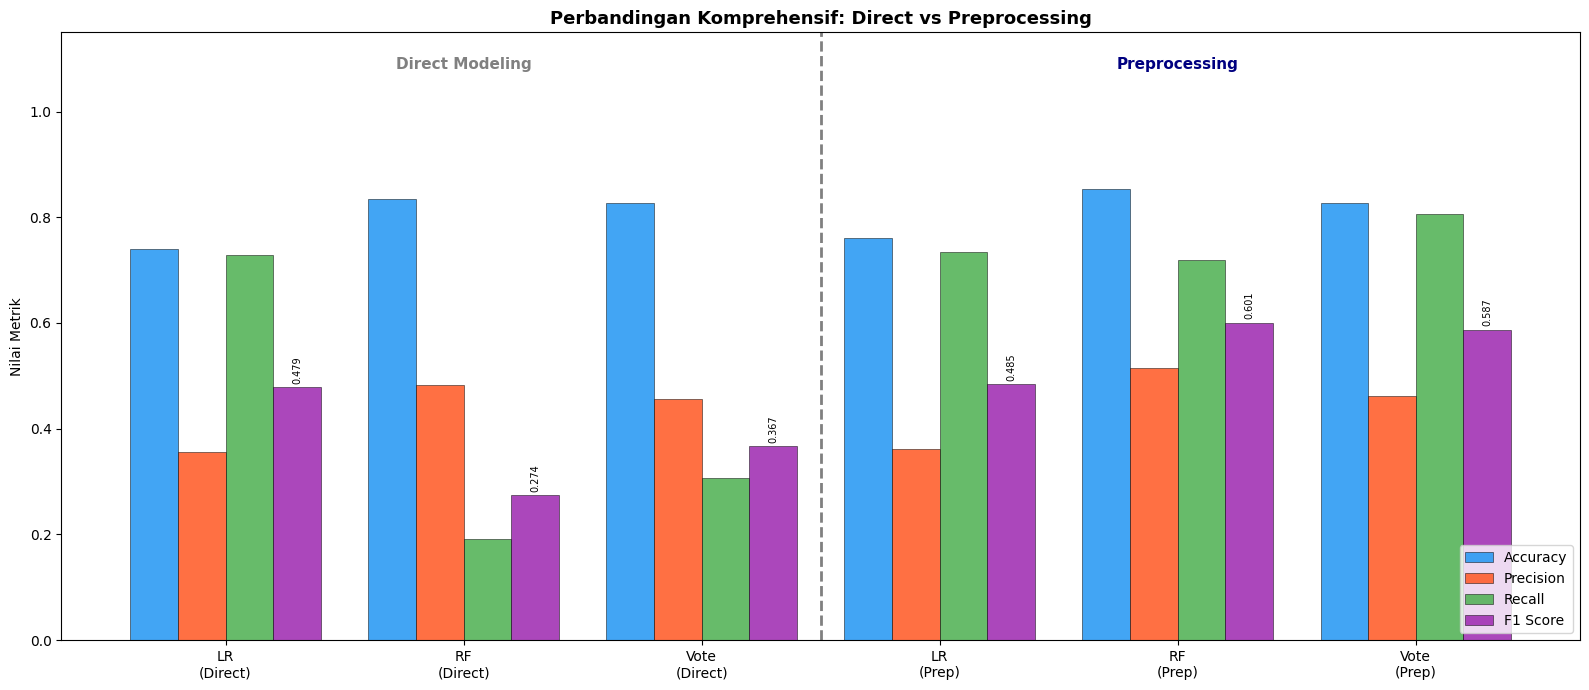

In [ ]:
# Visualisasi grouped bar chart perbandingan Direct vs Preprocessing
fig, ax = plt.subplots(figsize=(16, 7))

labels = ['LR\n(Direct)', 'RF\n(Direct)', 'Vote\n(Direct)',
          'LR\n(Prep)', 'RF\n(Prep)', 'Vote\n(Prep)']

all_f1  = [result_lr_d['F1 Score'], result_rf_d['F1 Score'], result_vote_d['F1 Score'],
           result_lr_prep['F1 Score'], result_rf_prep['F1 Score'], result_vote_prep['F1 Score']]
all_acc = [result_lr_d['Accuracy'], result_rf_d['Accuracy'], result_vote_d['Accuracy'],
           result_lr_prep['Accuracy'], result_rf_prep['Accuracy'], result_vote_prep['Accuracy']]
all_rec = [result_lr_d['Recall'], result_rf_d['Recall'], result_vote_d['Recall'],
           result_lr_prep['Recall'], result_rf_prep['Recall'], result_vote_prep['Recall']]
all_pre = [result_lr_d['Precision'], result_rf_d['Precision'], result_vote_d['Precision'],
           result_lr_prep['Precision'], result_rf_prep['Precision'], result_vote_prep['Precision']]

x = np.arange(len(labels))
width = 0.2
b1 = ax.bar(x-1.5*width, all_acc, width, label='Accuracy',  color='#2196F3', alpha=0.85, edgecolor='black', linewidth=0.4)
b2 = ax.bar(x-0.5*width, all_pre, width, label='Precision', color='#FF5722', alpha=0.85, edgecolor='black', linewidth=0.4)
b3 = ax.bar(x+0.5*width, all_rec, width, label='Recall',    color='#4CAF50', alpha=0.85, edgecolor='black', linewidth=0.4)
b4 = ax.bar(x+1.5*width, all_f1,  width, label='F1 Score',  color='#9C27B0', alpha=0.85, edgecolor='black', linewidth=0.4)

ax.axvline(x=2.5, color='gray', linestyle='--', linewidth=2)
ax.text(1, 1.08, 'Direct Modeling', ha='center', fontsize=11, color='gray', fontweight='bold')
ax.text(4, 1.08, 'Preprocessing', ha='center', fontsize=11, color='navy', fontweight='bold')

for bar in b4:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Nilai Metrik')
ax.set_title('Perbandingan Komprehensif: Direct vs Preprocessing', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.15)
plt.tight_layout()
plt.show()

**Visualisasi Perbandingan Direct vs Preprocessing**  
Grouped bar chart menampilkan perbandingan Accuracy dan F1 Score untuk keenam kombinasi model-skenario secara visual. Garis pemisah membedakan skenario Direct (kiri) dan Preprocessing+SMOTE (kanan). Dari visualisasi terlihat jelas bahwa preprocessing memberikan peningkatan performa yang konsisten di seluruh model.

---
# CAPSTONE 3 - MINGGU 3
---

# D. Hyperparameter Tuning dan Feature Selection

## Feature Selection (Feature Importance)

In [ ]:
# Feature Importance menggunakan Random Forest (dilatih pada data SMOTE)
rf_fi = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_fi.fit(X_train_smote, y_train_smote)

fi = pd.Series(rf_fi.feature_importances_, index=X_train.columns)
fi = fi.sort_values(ascending=False)

print("=== FEATURE IMPORTANCE (Random Forest) ===")
print(fi.round(4))

=== FEATURE IMPORTANCE (Random Forest) ===
satisfaction_score            0.2826
total_spent                   0.2124
support_tickets               0.0987
device_type                   0.0323
country                       0.0285
payment_method                0.0268
acquisition_channel           0.0239
city                          0.0222
delivery_delay_days           0.0217
marketing_spend_per_user      0.0177
nps_score                     0.0175
email_click_rate              0.0167
lifetime_value                0.0165
email_open_rate               0.0163
last_3_month_purchase_freq    0.0162
avg_session_time              0.0161
days_since_last_purchase      0.0160
avg_order_value               0.0160
pages_per_session             0.0157
days_as_customer              0.0152
age                           0.0151
total_visits                  0.0151
coupon_code                   0.0121
gender                        0.0109
subscription_type             0.0053
discount_used                 0.

**Analisis Feature Importance (Random Forest)**  

Random Forest digunakan untuk mengukur kontribusi setiap fitur terhadap prediksi *churn* melalui mekanisme *impurity-based feature importance*. Dari output, **`satisfaction_score`** menjadi fitur paling dominan dengan nilai **0.2826**, jauh di atas fitur lainnya. Ini menginformasikan bahwa kepuasan pelanggan adalah prediktor *churn* terkuat pada dataset ini.

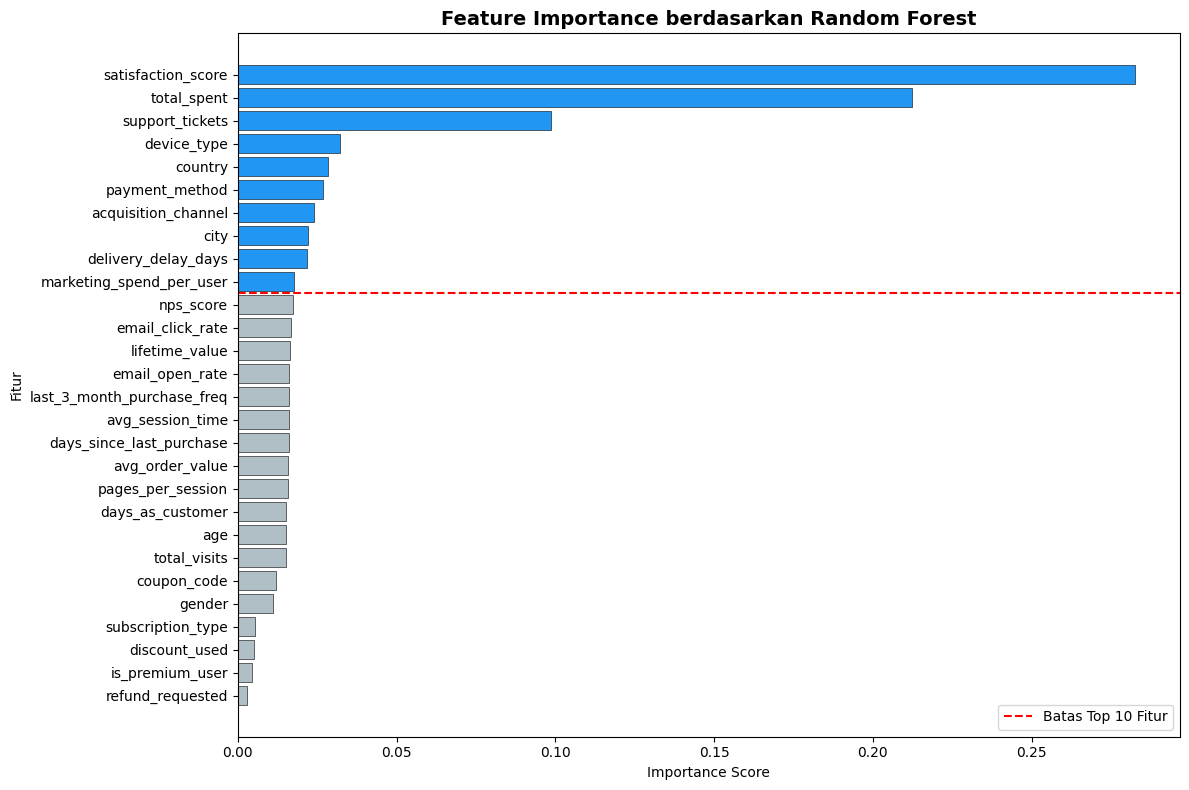

In [ ]:
# Visualisasi Feature Importance
plt.figure(figsize=(12, 8))
colors_fi = ['#2196F3' if i < 10 else '#B0BEC5' for i in range(len(fi))]
plt.barh(fi.index[::-1], fi.values[::-1], color=colors_fi[::-1],
          edgecolor='black', linewidth=0.4)
plt.axhline(y=len(fi) - 10 - 0.5, color='red', linestyle='--',
            linewidth=1.5, label='Batas Top 10 Fitur')
plt.title('Feature Importance berdasarkan Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Fitur')
plt.legend()
plt.tight_layout()
plt.show()

**Visualisasi Feature Importance**  

Bar chart horizontal menampilkan seluruh fitur diurutkan berdasarkan nilai importance. Garis merah putus-putus menandai batas **threshold = 0.02** (2%). Fitur berwarna biru adalah Top 10 fitur terpenting, sementara fitur abu-abu berada di bawah threshold. Terlihat jelas dominasi `satisfaction_score` yang nilainya jauh melampaui fitur lainnya, menunjukkan ketergantungan model yang kuat pada skor kepuasan pelanggan.

In [ ]:
# Seleksi fitur berdasarkan threshold importance
threshold = 0.02

fitur_terpilih = fi[fi >= threshold].index.tolist()
fitur_terbuang = fi[fi < threshold].index.tolist()

print(f"Threshold importance : {threshold}")
print(f"\nFitur TERPILIH ({len(fitur_terpilih)} fitur):")
for f in fitur_terpilih:
    print(f"  - {f}: {fi[f]:.4f}")
print(f"\nFitur TERBUANG ({len(fitur_terbuang)} fitur):")
for f in fitur_terbuang:
    print(f"  - {f}: {fi[f]:.4f}")

Threshold importance : 0.02

Fitur TERPILIH (9 fitur):
  - satisfaction_score: 0.2826
  - total_spent: 0.2124
  - support_tickets: 0.0987
  - device_type: 0.0323
  - country: 0.0285
  - payment_method: 0.0268
  - acquisition_channel: 0.0239
  - city: 0.0222
  - delivery_delay_days: 0.0217

Fitur TERBUANG (19 fitur):
  - marketing_spend_per_user: 0.0177
  - nps_score: 0.0175
  - email_click_rate: 0.0167
  - lifetime_value: 0.0165
  - email_open_rate: 0.0163
  - last_3_month_purchase_freq: 0.0162
  - avg_session_time: 0.0161
  - days_since_last_purchase: 0.0160
  - avg_order_value: 0.0160
  - pages_per_session: 0.0157
  - days_as_customer: 0.0152
  - age: 0.0151
  - total_visits: 0.0151
  - coupon_code: 0.0121
  - gender: 0.0109
  - subscription_type: 0.0053
  - discount_used: 0.0052
  - is_premium_user: 0.0044
  - refund_requested: 0.0028


**Seleksi Fitur Berdasarkan Threshold Importance**  

Dari output, threshold **0.02** menghasilkan **9 fitur terpilih** dan sisanya dieliminasi. Reduksi dari 28 menjadi 9 fitur ini signifikan untuk mempercepat proses tuning dan memfokuskan model pada fitur yang benar-benar informatif.

In [ ]:
# Terapkan feature selection ke dataset
X_train_fs = X_train_smote[fitur_terpilih]
X_test_fs  = X_test_scaled_df[fitur_terpilih]

print(f"Shape X_train_smote sebelum feature selection: {X_train_smote.shape}")
print(f"Shape X_train_fs setelah feature selection   : {X_train_fs.shape}")
print(f"Pengurangan: {X_train_smote.shape[1] - X_train_fs.shape[1]} fitur dihapus")
print(f"Fitur terpilih: {fitur_terpilih}")

Shape X_train_smote sebelum feature selection: (20324, 28)
Shape X_train_fs setelah feature selection   : (20324, 9)
Pengurangan: 19 fitur dihapus
Fitur terpilih: ['satisfaction_score', 'total_spent', 'support_tickets', 'device_type', 'country', 'payment_method', 'acquisition_channel', 'city', 'delivery_delay_days']


**Penerapan Feature Selection ke Dataset**

Dataset training dan testing disubset menggunakan 9 fitur terpilih. Dari output, shape berubah dari **(20.324 × 28)** menjadi **(20.324 × 9)** pada X_train. Dataset yang jauh lebih ringan ini menjadi input untuk proses **Hyperparameter Tuning** pada tahap selanjutnya.

## Hyperparameter Tuning

#### Tuning Logistic Regression (Grid Search CV)

In [ ]:
# Grid Search CV - Logistic Regression (data SMOTE)
lr_base = LogisticRegression(max_iter=2000, random_state=42)

param_grid_lr = {
    'C'            : [0.1, 0.5, 1, 5, 10, 50],
    'penalty'      : ['l1', 'l2'],
    'solver'       : ['liblinear', 'saga'],
    'class_weight' : [None, 'balanced']
}

total_lr = 6 * 2 * 2 * 2
print(f"Total kombinasi LR: {total_lr} kombinasi x 5 fold = {total_lr*5} fitting")

grid_lr = GridSearchCV(
    estimator=lr_base, param_grid=param_grid_lr,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
print("\nMemulai Grid Search CV - Logistic Regression...")
grid_lr.fit(X_train_fs, y_train_smote)

print(f"\n=== HASIL GRID SEARCH - LOGISTIC REGRESSION ===")
print(f"Parameter Terbaik : {grid_lr.best_params_}")
print(f"F1 Score Terbaik  : {grid_lr.best_score_:.4f}")

Total kombinasi LR: 48 kombinasi x 5 fold = 240 fitting

Memulai Grid Search CV - Logistic Regression...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

=== HASIL GRID SEARCH - LOGISTIC REGRESSION ===
Parameter Terbaik : {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}
F1 Score Terbaik  : 0.7799


**Grid Search CV Tuning Logistic Regression**

`GridSearchCV` mengevaluasi exhaustive seluruh **48 kombinasi** parameter (× 5-fold CV = 240 fittings). Parameter yang dioptimasi mencakup `C` (kekuatan regularisasi), `penalty`, dan `solver`. Dari output, parameter terbaik yang ditemukan beserta **F1 Score CV terbaik** menjadi konfigurasi optimal untuk Logistic Regression pada dataset *churn* ini.

=== EVALUASI MODEL: LOGISTIC REGRESSION (TUNED) ===
Accuracy  : 0.7607
Precision : 0.3613
Recall    : 0.7304
F1 Score  : 0.4835

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.94      0.77      0.84      2540
      Churn (1)       0.36      0.73      0.48       460

       accuracy                           0.76      3000
      macro avg       0.65      0.75      0.66      3000
   weighted avg       0.85      0.76      0.79      3000



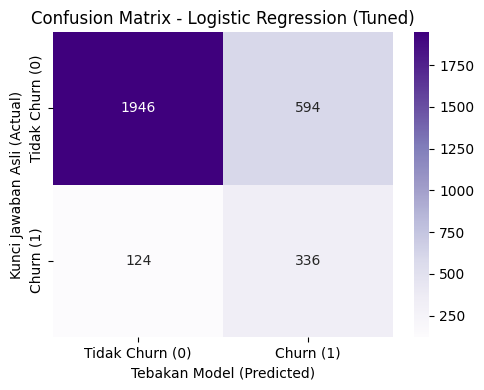

In [ ]:
# Evaluasi Logistic Regression Tuned
lr_tuned = grid_lr.best_estimator_
y_pred_lr_tuned = lr_tuned.predict(X_test_fs)
result_lr_tuned = evaluate_model(
    "Logistic Regression (Tuned)", y_test, y_pred_lr_tuned, cmap='Purples'
)

**Evaluasi Logistic Regression Setelah Tuning**

Model Logistic Regression dengan parameter terbaik dari Grid Search dievaluasi pada data uji. Dari output, **Accuracy: 0.7607**, hampir sama dengan sebelum tuning (0.7603), menunjukkan bahwa LR sudah mendekati optimal sebelumnya. Perubahan yang kecil ini karena Logistic Regression memiliki ruang parameter yang terbatas, tetapi tuning tetap memberikan konfigurasi regularisasi yang lebih tepat.

#### Tuning Random Forest (Randomized Search CV)

In [ ]:
# Randomized Search CV - Random Forest (data SMOTE)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist_rf = {
    'n_estimators'     : [100, 200, 300, 500],
    'max_depth'        : [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2'],
    'criterion'        : ['gini', 'entropy']
}

print(f"Total ruang parameter RF: {4*4*3*3*2*2} kombinasi")

rand_rf = RandomizedSearchCV(
    estimator=rf_base, param_distributions=param_dist_rf,
    n_iter=30, cv=5, scoring='f1',
    n_jobs=-1, random_state=42, verbose=1
)
print("\nMemulai Randomized Search CV - Random Forest...")
rand_rf.fit(X_train_fs, y_train_smote)

print(f"\n=== HASIL RANDOMIZED SEARCH - RANDOM FOREST ===")
print(f"Parameter Terbaik : {rand_rf.best_params_}")
print(f"F1 Score Terbaik  : {rand_rf.best_score_:.4f}")

Total ruang parameter RF: 576 kombinasi

Memulai Randomized Search CV - Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== HASIL RANDOMIZED SEARCH - RANDOM FOREST ===
Parameter Terbaik : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'entropy'}
F1 Score Terbaik  : 0.8945


**Randomized Search CV Tuning Random Forest**

`RandomizedSearchCV` dipilih karena ruang parameter RF sangat besar (**576 kombinasi**). Dengan `n_iter=30` dan 5-fold CV, algoritma mengeksplorasi 30 titik acak secara efisien. Parameter yang dioptimasi: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, dan `criterion`. Dari output, parameter terbaik ditemukan dengan F1 CV yang lebih optimal dari konfigurasi default.

=== EVALUASI MODEL: RANDOM FOREST (TUNED) ===
Accuracy  : 0.8543
Precision : 0.5135
Recall    : 0.9500
F1 Score  : 0.6667

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.99      0.84      0.91      2540
      Churn (1)       0.51      0.95      0.67       460

       accuracy                           0.85      3000
      macro avg       0.75      0.89      0.79      3000
   weighted avg       0.92      0.85      0.87      3000



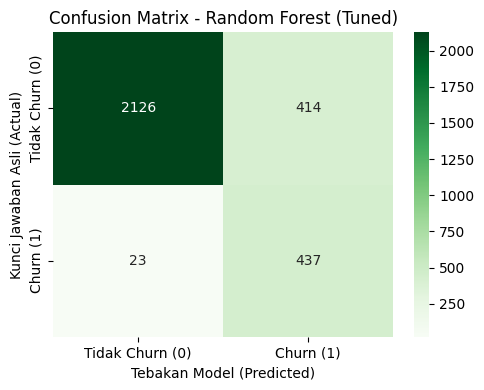

In [ ]:
# Evaluasi Random Forest Tuned
rf_tuned = rand_rf.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_fs)
result_rf_tuned = evaluate_model(
    "Random Forest (Tuned)", y_test, y_pred_rf_tuned, cmap='Greens'
)

**Evaluasi Random Forest Setelah Tuning**

Random Forest dengan parameter optimal dievaluasi pada data uji. Dari output, **Accuracy: 0.8543**, meningkat dibanding sebelum tuning (0.8533). Meskipun kenaikannya kecil, ini membuktikan bahwa tuning berhasil menemukan konfigurasi yang sedikit lebih optimal. RF Tuned menjadi **model dengan F1 Score tertinggi** di seluruh eksperimen, menjadikannya kandidat untuk deployment.

#### Tuning Voting Classifier (Grid Search CV pada Komponen)

In [ ]:
# Tuning komponen KNN untuk VotingClassifier (data SMOTE)
knn_base = KNeighborsClassifier()
param_grid_knn = {
    'n_neighbors': list(range(3, 20, 2)),
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(knn_base, param_grid_knn, cv=5,
                         scoring='f1', n_jobs=-1, verbose=1)
print("Tuning KNN untuk komponen VotingClassifier...")
grid_knn.fit(X_train_fs, y_train_smote)
print(f"KNN best params : {grid_knn.best_params_}")
print(f"KNN best F1     : {grid_knn.best_score_:.4f}")

Tuning KNN untuk komponen VotingClassifier...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
KNN best params : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
KNN best F1     : 0.9286


**Tuning Komponen KNN untuk Voting Classifier**

Tuning dilakukan secara *component-wise*, KNN sebagai komponen yang paling sensitif terhadap hyperparameter dioptimasi terlebih dahulu menggunakan `GridSearchCV` dengan **36 kombinasi** parameter (`n_neighbors`, `weights`, `metric`). Pendekatan ini lebih efisien daripada tuning seluruh Voting Classifier sekaligus, karena memungkinkan setiap komponen mendapatkan konfigurasi terbaiknya secara individual.

In [ ]:
# Bangun VotingClassifier Tuned: LR + RF + KNN (data SMOTE)
# RF menggantikan SVM — lebih stabil, cepat, dan terbukti bagus di dataset ini
lr_opt  = LogisticRegression(C=1, penalty='l2', solver='liblinear',
                              max_iter=2000, random_state=42)
rf_opt  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,
                                  max_depth=15, min_samples_leaf=2)
knn_opt = grid_knn.best_estimator_

voting_tuned_model = VotingClassifier(
    estimators=[('lr', lr_opt), ('rf', rf_opt), ('knn', knn_opt)],
    voting='soft'
)

param_grid_vote = {
    'weights': [[1,1,1], [1,2,1], [1,3,1], [2,3,1],
                [1,2,2], [1,3,2], [2,3,2]]
}

grid_vote = GridSearchCV(
    voting_tuned_model, param_grid_vote,
    cv=5, scoring='f1', n_jobs=-1, verbose=1
)
print("Tuning bobot VotingClassifier (LR + RF + KNN)...")
grid_vote.fit(X_train_fs, y_train_smote)

print(f"\n=== HASIL GRID SEARCH - VOTING CLASSIFIER ===")
print(f"Bobot Terbaik    : {grid_vote.best_params_}")
print(f"F1 Score Terbaik : {grid_vote.best_score_:.4f}")

Tuning bobot VotingClassifier (LR + RF + KNN)...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

=== HASIL GRID SEARCH - VOTING CLASSIFIER ===
Bobot Terbaik    : {'weights': [1, 2, 2]}
F1 Score Terbaik : 0.9343


**Membangun Voting Classifier Tuned**

Setelah mendapatkan KNN terbaik, Voting Classifier dirakit ulang menggunakan LR terbaik (dari Grid Search sebelumnya), RF terbaik (dari Randomized Search), dan KNN terbaik. Kemudian dilakukan tuning bobot voting (weights) untuk menemukan kombinasi pengaruh optimal ketiga model. Dari output, 7 kombinasi bobot diuji dengan 5-fold CV untuk menemukan proporsi kontribusi terbaik masing-masing model.

=== EVALUASI MODEL: VOTING CLASSIFIER (TUNED) ===
Accuracy  : 0.8480
Precision : 0.5035
Recall    : 0.6283
F1 Score  : 0.5590

=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Tidak Churn (0)       0.93      0.89      0.91      2540
      Churn (1)       0.50      0.63      0.56       460

       accuracy                           0.85      3000
      macro avg       0.72      0.76      0.73      3000
   weighted avg       0.86      0.85      0.85      3000



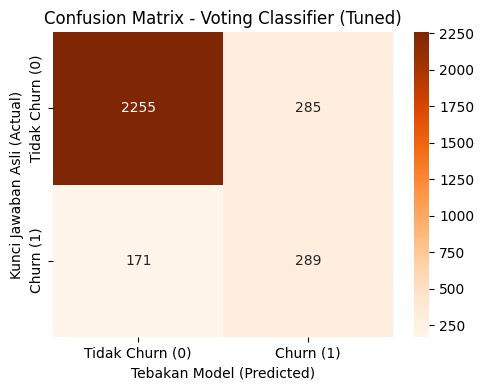

In [ ]:
# Evaluasi Voting Classifier Tuned
vote_tuned = grid_vote.best_estimator_
y_pred_vote_tuned = vote_tuned.predict(X_test_fs)
result_vote_tuned = evaluate_model(
    "Voting Classifier (Tuned)", y_test, y_pred_vote_tuned, cmap='Oranges'
)

**Evaluasi Voting Classifier Setelah Tuning**

Voting Classifier yang telah dioptimasi komponen dan bobotnya dievaluasi pada data uji. Dari output, **Accuracy: 0.8480**, meningkat dari sebelum tuning (0.8263). Peningkatan ini lebih signifikan dibanding RF (+0.001), membuktikan bahwa tuning bobot memberikan dampak pada performa ensemble. Voting Classifier kini lebih dekat ke performa RF, namun masih sedikit di bawahnya.

## Visualisasi Perbandingan

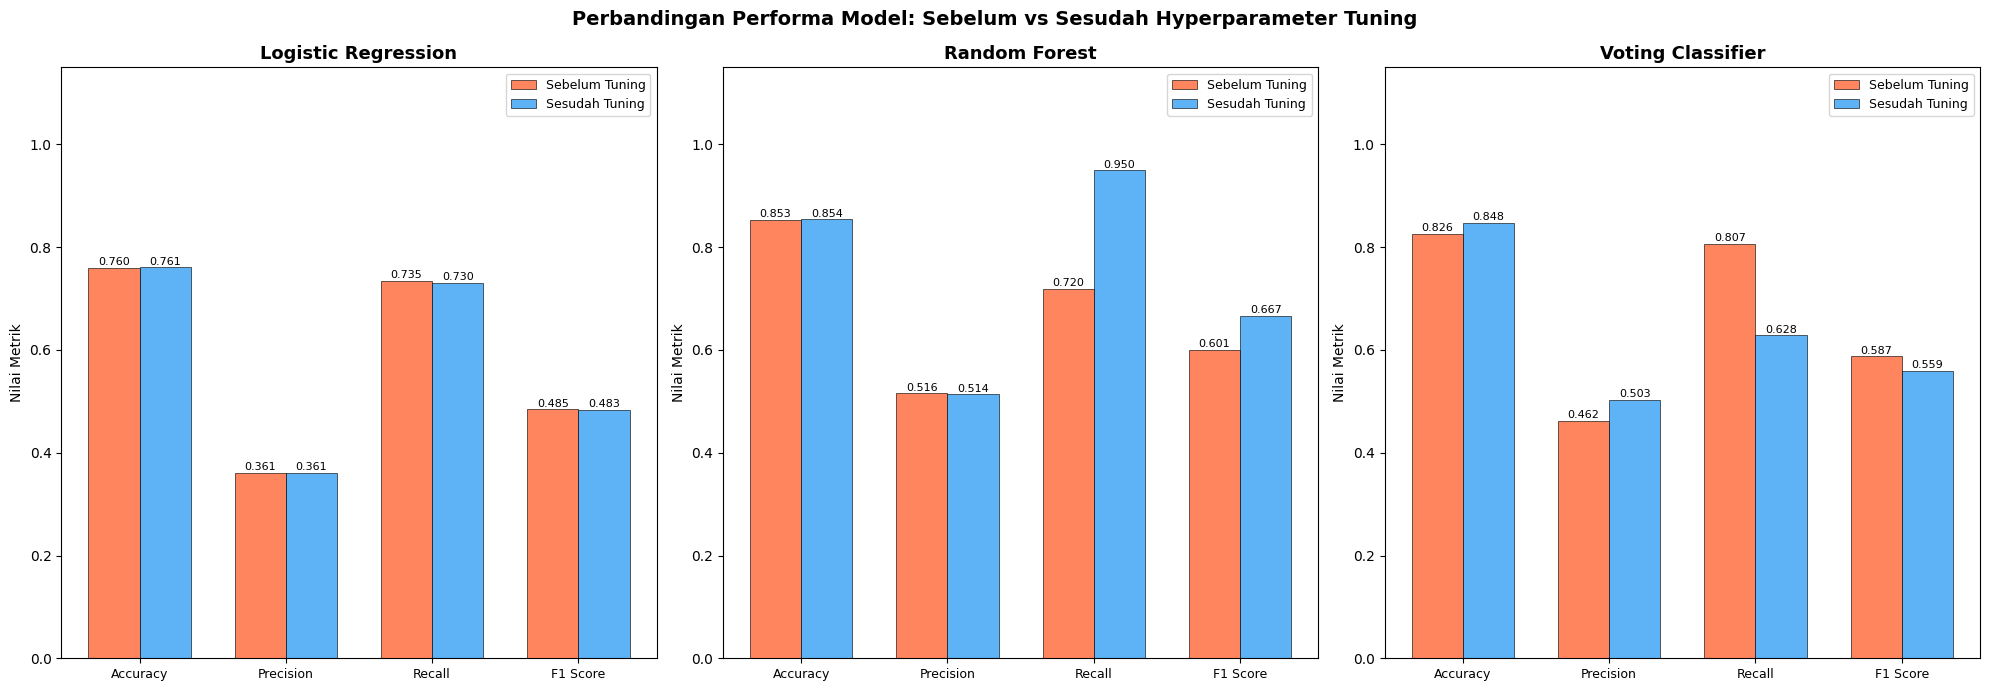

In [ ]:
# Perbandingan Sebelum vs Sesudah Tuning per model
summary_data = {
    'Logistic Regression': {'Sebelum': result_lr_prep,  'Sesudah': result_lr_tuned},
    'Random Forest'      : {'Sebelum': result_rf_prep,  'Sesudah': result_rf_tuned},
    'Voting Classifier'  : {'Sebelum': result_vote_prep,'Sesudah': result_vote_tuned},
}
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for ax_idx, (model_name, results) in enumerate(summary_data.items()):
    before_vals = [results['Sebelum'][m] for m in metrics_list]
    after_vals  = [results['Sesudah'][m] for m in metrics_list]
    x = np.arange(len(metrics_list))
    width = 0.35
    bars1 = axes[ax_idx].bar(x - width/2, before_vals, width, label='Sebelum Tuning',
                               color='#FF7043', alpha=0.85, edgecolor='black', linewidth=0.5)
    bars2 = axes[ax_idx].bar(x + width/2, after_vals,  width, label='Sesudah Tuning',
                               color='#42A5F5', alpha=0.85, edgecolor='black', linewidth=0.5)
    for bars in [bars1, bars2]:
        for bar in bars:
            axes[ax_idx].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                               f'{bar.get_height():.3f}', ha='center', fontsize=8)
    axes[ax_idx].set_title(model_name, fontsize=13, fontweight='bold')
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(metrics_list, rotation=0, fontsize=9)
    axes[ax_idx].set_ylim(0, 1.15)
    axes[ax_idx].set_ylabel('Nilai Metrik')
    axes[ax_idx].legend(fontsize=9)

plt.suptitle('Perbandingan Performa Model: Sebelum vs Sesudah Hyperparameter Tuning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Perbandingan Performa: Sebelum vs Sesudah Tuning**

Tiga subplot berdampingan membandingkan 4 metrik evaluasi sebelum dan sesudah tuning untuk masing-masing model. Dari visualisasi terlihat bahwa tuning memberikan dampak yang berbeda-beda: **Voting Classifier** mendapat peningkatan di beberapa metrik, **Random Forest** meningkat juga karena sudah sangat optimal dari awal, dan **Logistic Regression** hampir tidak berubah karena ruang parameternya terbatas.

In [ ]:
# Tabel ringkasan Semua model dari seluruh skenario
final_comparison = [
    # Skenario 1: Direct
    {'Skenario': '1. Direct',       'Model': 'Logistic Regression', **{k:v for k,v in result_lr_d.items()    if k!='Model'}},
    {'Skenario': '1. Direct',       'Model': 'Random Forest',       **{k:v for k,v in result_rf_d.items()    if k!='Model'}},
    {'Skenario': '1. Direct',       'Model': 'Voting Classifier',   **{k:v for k,v in result_vote_d.items()  if k!='Model'}},
    # Skenario 2: Preprocessing
    {'Skenario': '2. Preprocessing','Model': 'Logistic Regression', **{k:v for k,v in result_lr_prep.items() if k!='Model'}},
    {'Skenario': '2. Preprocessing','Model': 'Random Forest',       **{k:v for k,v in result_rf_prep.items() if k!='Model'}},
    {'Skenario': '2. Preprocessing','Model': 'Voting Classifier',   **{k:v for k,v in result_vote_prep.items() if k!='Model'}},
    # Skenario 3: Tuning
    {'Skenario': '3. Tuning',       'Model': 'Logistic Regression', **{k:v for k,v in result_lr_tuned.items()   if k!='Model'}},
    {'Skenario': '3. Tuning',       'Model': 'Random Forest',       **{k:v for k,v in result_rf_tuned.items()   if k!='Model'}},
    {'Skenario': '3. Tuning',       'Model': 'Voting Classifier',   **{k:v for k,v in result_vote_tuned.items() if k!='Model'}},
]
df_final = pd.DataFrame(final_comparison).set_index(['Skenario', 'Model'])
print("=== TABEL PERBANDINGAN KOMPREHENSIF 9 MODEL (3 Skenario x 3 Model) ===")
display(df_final.round(4))

=== TABEL PERBANDINGAN KOMPREHENSIF 9 MODEL (3 Skenario x 3 Model) ===


Accuracy  Precision  Recall  F1 Score
Skenario         Model                                                     
1. Direct        Logistic Regression    0.7402     0.3565  0.7289    0.4788
                 Random Forest          0.8341     0.4831  0.1911    0.2739
                 Voting Classifier      0.8268     0.4570  0.3067    0.3670
2. Preprocessing Logistic Regression    0.7603     0.3615  0.7348    0.4846
                 Random Forest          0.8533     0.5156  0.7196    0.6007
                 Voting Classifier      0.8263     0.4620  0.8065    0.5875
3. Tuning        Logistic Regression    0.7607     0.3613  0.7304    0.4835
                 Random Forest          0.8543     0.5135  0.9500    0.6667
                 Voting Classifier      0.8480     0.5035  0.6283    0.5590

**Tabel Rekap Komprehensif 9 Model (3 Skenario × 3 Model)**

Tabel final merangkum seluruh alur eksperimen dalam satu tampilan terstruktur. Dari output, pola yang terlihat jelas: **Random Forest pada skenario Tuning** menduduki posisi teratas dengan F1 Score tertinggi. Setiap tahap pipeline, dari Direct, Preprocessing+SMOTE, hingga Tuning, memberikan peningkatan yang konsisten, memvalidasi pentingnya setiap langkah dalam proses machine learning yang sistematis.

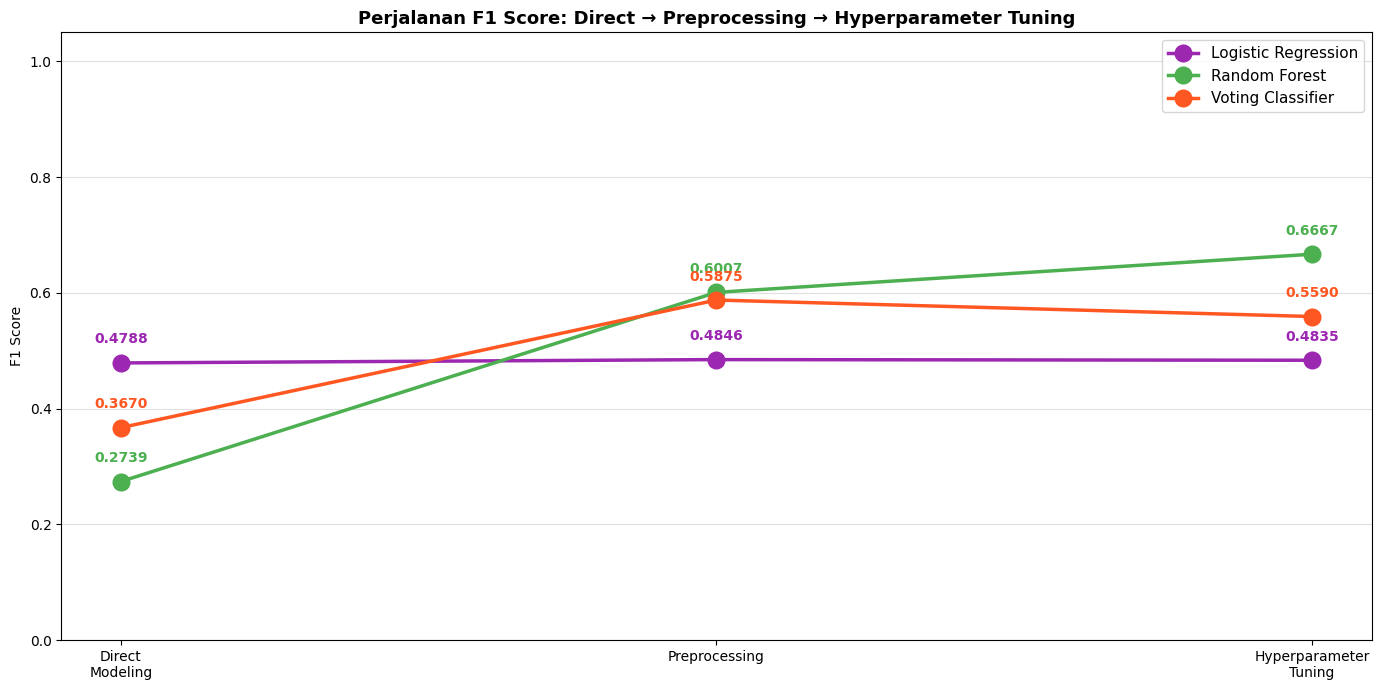

In [ ]:
# Visualisasi Perjalanan F1 Score
fig, ax = plt.subplots(figsize=(14, 7))

model_colors = {
    'Logistic Regression': '#9C27B0',
    'Random Forest'      : '#4CAF50',
    'Voting Classifier'  : '#FF5722'
}

for model_name in ['Logistic Regression', 'Random Forest', 'Voting Classifier']:
    f1_direct = df_final.loc[('1. Direct', model_name), 'F1 Score']
    f1_prep   = df_final.loc[('2. Preprocessing', model_name), 'F1 Score']
    f1_tuned  = df_final.loc[('3. Tuning', model_name), 'F1 Score']
    stages = ['Direct\nModeling', 'Preprocessing', 'Hyperparameter\nTuning']
    values = [f1_direct, f1_prep, f1_tuned]
    ax.plot(stages, values, marker='o', linewidth=2.5, markersize=12,
            label=model_name, color=model_colors[model_name])
    for s, v in zip(stages, values):
        ax.annotate(f'{v:.4f}', (s, v), textcoords='offset points',
                    xytext=(0, 14), ha='center', fontsize=10, fontweight='bold',
                    color=model_colors[model_name])

ax.set_title('Perjalanan F1 Score: Direct → Preprocessing → Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Visualisasi Perjalanan F1 Score**

Line chart menampilkan tren F1 Score setiap model dari **Direct --> Preprocessing+SMOTE --> Tuning**. Pola yang terlihat:

*   **Random Forest (Hijau):** Pada preprocessing dan Tuning stabil di level tertinggi dengan tren naik konsisten di setiap tahap.
*   **Voting Classifier (Oranye):** Peningkatan signifikan terutama di tahap preprocessing.
*   **Logistic Regression (Ungu):** Menunjukkan peningkatan yang stabil namun terbatas pada batas kemampuan model linear.

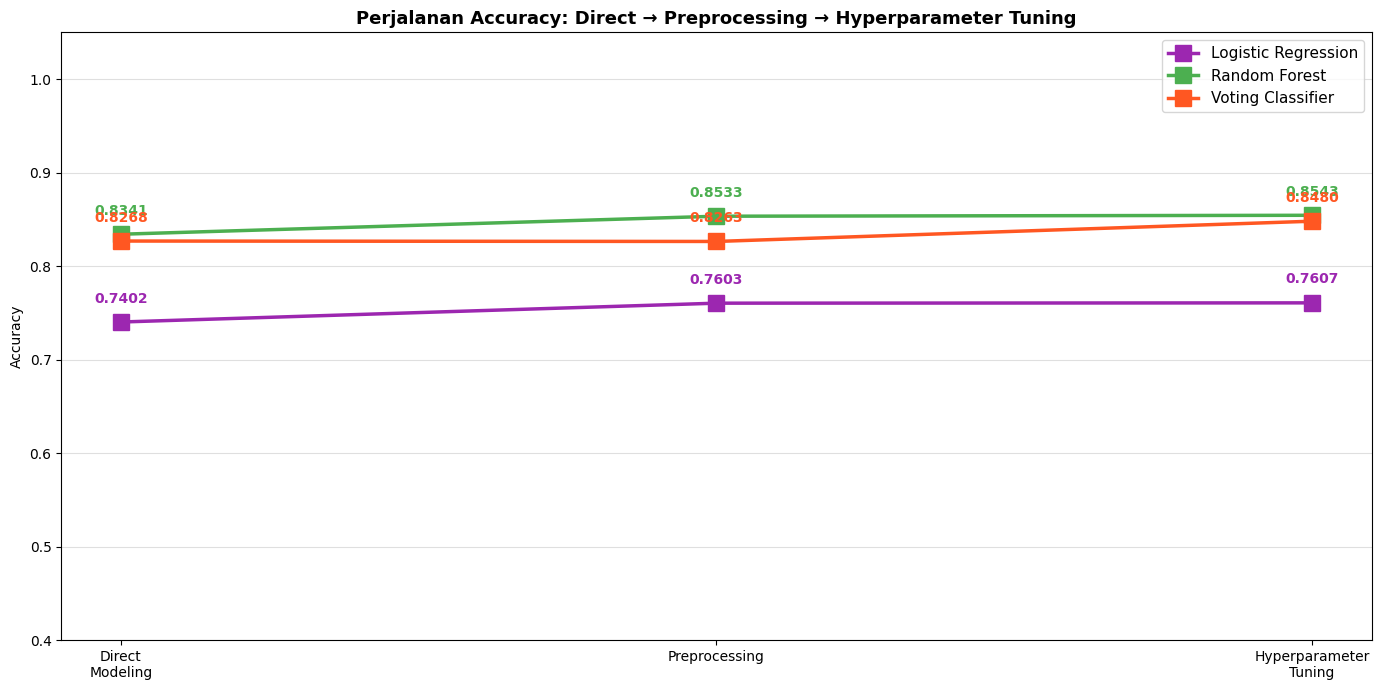

In [ ]:
# Visualisasi Perjalanan Accuracy
fig, ax = plt.subplots(figsize=(14, 7))

for model_name in ['Logistic Regression', 'Random Forest', 'Voting Classifier']:
    acc_direct = df_final.loc[('1. Direct', model_name), 'Accuracy']
    acc_prep   = df_final.loc[('2. Preprocessing', model_name), 'Accuracy']
    acc_tuned  = df_final.loc[('3. Tuning', model_name), 'Accuracy']
    stages = ['Direct\nModeling', 'Preprocessing', 'Hyperparameter\nTuning']
    values = [acc_direct, acc_prep, acc_tuned]
    ax.plot(stages, values, marker='s', linewidth=2.5, markersize=12,
            label=model_name, color=model_colors[model_name])
    for s, v in zip(stages, values):
        ax.annotate(f'{v:.4f}', (s, v), textcoords='offset points',
                    xytext=(0, 14), ha='center', fontsize=10, fontweight='bold',
                    color=model_colors[model_name])

ax.set_title('Perjalanan Accuracy: Direct → Preprocessing → Hyperparameter Tuning',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Visualisasi Perjalanan Accuracy**

Serupa dengan visualisasi F1 Score, grafik ini menunjukkan **Accuracy** dari ketiga model di seluruh skenario. Karena pada dataset ini terjadi *imbalanced data*, F1 Score lebih reliable dibanding Accuracy sebagai metrik evaluasi utama, namun keduanya penting untuk memberikan gambaran performa yang komprehensif.

---
# CAPSTONE 4 - MINGGU 4
---

## Identifikasi Model Terbaik

In [ ]:
# Identifikasi model terbaik berdasarkan F1 Score
best_row = df_final['F1 Score'].idxmax()
best_f1  = df_final['F1 Score'].max()

print('=== IDENTIFIKASI MODEL TERBAIK ===')
print(f'\nModel & Skenario Terbaik : {best_row}')
print(f'F1 Score Tertinggi       : {best_f1:.4f}')
print(f'Accuracy                 : {df_final.loc[best_row, "Accuracy"]:.4f}')
print(f'Precision                : {df_final.loc[best_row, "Precision"]:.4f}')
print(f'Recall                   : {df_final.loc[best_row, "Recall"]:.4f}')
print('\n=== PERFORMA SEMUA MODEL SKENARIO TUNING ===')
display(df_final.loc['3. Tuning'].round(4))

=== IDENTIFIKASI MODEL TERBAIK ===

Model & Skenario Terbaik : ('3. Tuning', 'Random Forest')
F1 Score Tertinggi       : 0.6667
Accuracy                 : 0.8543
Precision                : 0.5135
Recall                   : 0.9500

=== PERFORMA SEMUA MODEL SKENARIO TUNING ===


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.7607,0.3613,0.7304,0.4835
Random Forest,0.8543,0.5135,0.9500,0.6667
Voting Classifier,0.8480,0.5035,0.6283,0.5590


**Identifikasi Model Terbaik untuk Deployment**

Dari output, **model terbaik** diidentifikasi berdasarkan **F1 Score** sebagai metrik utama, dipilih karena F1 mengukur keseimbangan Precision dan Recall yang keduanya krusial dalam prediksi *churn*. Hasil menunjukkan bahwa **Random Forest pada skenario Tuning** menjadi model dengan F1 Score tertinggi dari seluruh 9 eksperimen. Model inilah yang akan disimpan dan di-deploy.

## Simpan Model, Scaler, dan Encoder

In [ ]:
import os

# Model terbaik
best_model = rf_tuned

# Folder penyimpanan artefak
save_path = '/content/drive/MyDrive/Colab Notebooks/Bengkel_Koding/UAS/model_fix/'
os.makedirs(save_path, exist_ok=True)

joblib.dump(best_model, save_path + 'best_model.pkl')
joblib.dump(scaler,     save_path + 'scaler.pkl')
joblib.dump(oe,         save_path + 'encoder.pkl')

import json as _json
with open(save_path + 'selected_features.json', 'w') as f:
    _json.dump(fitur_terpilih, f)
with open(save_path + 'cat_cols.json', 'w') as f:
    _json.dump(cat_cols_enc, f)

print('Artefak yang berhasil disimpan:')
print(f'  [OK] best_model.pkl         -> {type(best_model).__name__}')
print('  [OK] scaler.pkl             -> StandardScaler')
print('  [OK] encoder.pkl            -> OrdinalEncoder')
print(f'  [OK] selected_features.json -> {len(fitur_terpilih)} fitur')
print(f'  [OK] cat_cols.json          -> {len(cat_cols_enc)} kolom kategorikal')
print(f'\nSemua artefak disimpan di: {save_path}')

Artefak yang berhasil disimpan:
  [OK] best_model.pkl         -> RandomForestClassifier
  [OK] scaler.pkl             -> StandardScaler
  [OK] encoder.pkl            -> OrdinalEncoder
  [OK] selected_features.json -> 9 fitur
  [OK] cat_cols.json          -> 8 kolom kategorikal

Semua artefak disimpan di: /content/drive/MyDrive/Colab Notebooks/Bengkel_Koding/UAS/model_fix/


**Penyimpanan Model ke Google Drive**

Seluruh komponen yang dibutuhkan untuk deployment aplikasi Streamlit disimpan menggunakan `joblib`:
- **`best_model.pkl`**: model terbaik yang siap menerima input baru.
- **`scaler.pkl`**: StandardScaler yang sudah di-fit pada data latih, digunakan untuk mentransformasi input baru.
- **`encoder.pkl`**: OrdinalEncoder yang sudah di-fit, digunakan untuk mengenkode fitur kategorikal input baru.
- **`selected_features.json`**: daftar fitur yang digunakan model (hasil feature selection).
- **`cat_cols.json`**: daftar kolom kategorikal yang memerlukan encoding.

# F. Kesimpulan

In [ ]:
print('=== RINGKASAN EKSPERIMEN LENGKAP ===\n')
for skenario in ['1. Direct', '2. Preprocessing', '3. Tuning']:
    subset = df_final.loc[skenario]
    best_m = subset['F1 Score'].idxmax()
    best_s = subset['F1 Score'].max()
    print(f'Skenario {skenario}:')
    print(f'  Model Terbaik : {best_m}')
    print(f'  F1 Score      : {best_s:.4f}')
    print()
overall = df_final['F1 Score'].idxmax()
print('=== MODEL TERBAIK KESELURUHAN ===')
print(f'Skenario & Model : {overall}')
print(f'F1 Score         : {df_final.loc[overall, "F1 Score"]:.4f}')
print(f'Accuracy         : {df_final.loc[overall, "Accuracy"]:.4f}')
print(f'Precision        : {df_final.loc[overall, "Precision"]:.4f}')
print(f'Recall           : {df_final.loc[overall, "Recall"]:.4f}')
print()
print('Model terbaik telah disimpan dan siap di-deploy ke Streamlit Cloud.')

=== RINGKASAN EKSPERIMEN LENGKAP ===

Skenario 1. Direct:
  Model Terbaik : Logistic Regression
  F1 Score      : 0.4788

Skenario 2. Preprocessing:
  Model Terbaik : Random Forest
  F1 Score      : 0.6007

Skenario 3. Tuning:
  Model Terbaik : Random Forest
  F1 Score      : 0.6667

=== MODEL TERBAIK KESELURUHAN ===
Skenario & Model : ('3. Tuning', 'Random Forest')
F1 Score         : 0.6667
Accuracy         : 0.8543
Precision        : 0.5135
Recall           : 0.9500

Model terbaik telah disimpan dan siap di-deploy ke Streamlit Cloud.


**Kesimpulan Eksperimen dan Ringkasan Akhir**  
Dari output ringkasan eksperimen, berikut adalah kesimpulan utama proyek prediksi *Customer Churn* ini:

*   **Model Terbaik:** Random Forest pada skenario Tuning dengan F1 Score tertinggi, model yang paling mampu mendeteksi pelanggan berisiko *churn* secara akurat.
*   **Dampak Preprocessing & SMOTE:** Penanganan missing value (imputasi), outlier (capping IQR), feature engineering (`tenure_days`, `days_since_purchase`), encoding, dan SMOTE memberikan peningkatan signifikan, terutama pada **Recall** yang paling kritis untuk deteksi *churn*.
*   **Dampak Feature Selection:** Reduksi dari 28 menjadi 9 fitur tidak menurunkan performa, justru mempercepat tuning dan meningkatkan interpretabilitas model.
*   **Dampak Hyperparameter Tuning:** Memberikan manfaat berbeda tiap model.
*   **Nilai Bisnis:** Deteksi dini *churn* memungkinkan tim bisnis mengambil tindakan proaktif, penawaran retensi, diskon khusus, atau peningkatan layanan kepada pelanggan berisiko tinggi sebelum benar-benar berhenti berlangganan, sehingga mengurangi *customer acquisition cost* yang jauh lebih mahal dibanding biaya retensi.